# CHX Analysis — Sox2 protein variability

All analysis of the cycloheximide (CHX) dose–response experiment.
- **Data**: `df_9` = `hESCs Rep2 all proteins and CHX.csv`
- **Column**: C02 (`CHX_COL = 2`)
- **Rows**: R01 (DMSO control) through R08 (lowest CHX concentration)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm

# ── Path to data (Put csv path here) ────────────────────────────────────────────────────────────────
csv_path9 = r""
df_9 = pd.read_csv(csv_path9)


## Configuration

In [ ]:
# ── Experiment layout ────────────────────────────────────────────────────────────
CHX_COL  = 2                  # C02
ROWS     = list(range(1, 9))  # R01..R08
DMSO_ROW = 1                  # R01 = DMSO control

CELL_LINE = "hESCs"
PROTEIN   = "Sox2"

K_COL = "k"
S_COL = "s"
Y_COL = "mean_IF_DR"   # protein abundance — CV computed on this

# ── CHX concentrations (μg/mL) per row ───────────────────────────────────────────
CHX_CONC = {
    1: 0.0,       # DMSO
    2: 0.4,       # highest
    3: 0.2,
    4: 0.1,
    5: 0.05,
    6: 0.025,
    7: 0.0125,
    8: 0.00625,   # lowest
}

# ── Filtering ────────────────────────────────────────────────────────────────────
NONNEG_COLS = [K_COL, S_COL, Y_COL]
TRIM_COLS   = [K_COL, S_COL, Y_COL]
TRIM_Q_LOW, TRIM_Q_HIGH = 0.02, 0.98

# ── Sliding-window settings ──────────────────────────────────────────────────────
WINDOW_FRAC  = 0.15
STEP_FRAC    = 0.02
WINDOW_N     = None   # override WINDOW_FRAC if set
STEP_N       = None   # override STEP_FRAC if set
MIN_WINDOW_N = 80
X_GRID_N     = 250

DPI = 300


## Helper functions

In [14]:
def add_rc_numbers(df, root_col="if_root"):
    root_id = df[root_col].astype(str).map(
        lambda s: os.path.basename(os.path.normpath(s))
    )
    extracted = root_id.str.extract(r"^r(\d+)c(\d+)")
    out = df.copy()
    out["r_num"] = extracted[0].astype("Int64")
    out["c_num"] = extracted[1].astype("Int64")
    return out


def drop_any_negative(df, cols):
    cols_present = [c for c in (cols or []) if c in df.columns]
    if not cols_present:
        return df.copy()
    vals = df[cols_present].apply(pd.to_numeric, errors="coerce")
    return df[~(vals.lt(0).any(axis=1))].copy()


def drop_outside_quantiles(df, cols, q_low, q_high):
    cols_present = [c for c in (cols or []) if c in df.columns]
    if not cols_present:
        return df.copy()
    vals = df[cols_present].apply(pd.to_numeric, errors="coerce")
    lows  = vals.quantile(q_low)
    highs = vals.quantile(q_high)
    keep  = ((vals >= lows) & (vals <= highs) | vals.isna()).all(axis=1)
    return df[keep].copy()


def get_chx_condition_df(df_chx, *, r_num, c_num):
    sub = df_chx[
        (df_chx["r_num"] == r_num) & (df_chx["c_num"] == c_num)
    ].copy()
    if sub.empty:
        return sub
    sub = drop_any_negative(sub, NONNEG_COLS)
    sub = drop_outside_quantiles(sub, TRIM_COLS, TRIM_Q_LOW, TRIM_Q_HIGH)
    return sub


def cv_std_over_mean(series):
    v = pd.to_numeric(series, errors="coerce").dropna()
    if len(v) < 2:
        return np.nan
    mu = float(v.mean())
    if mu == 0 or np.isnan(mu):
        return np.nan
    return float(v.std(ddof=1)) / mu


# ── Colour helpers ────────────────────────────────────────────────────────────────
_positive_concs = sorted(c for c in CHX_CONC.values() if c > 0)
_log_norm = LogNorm(vmin=min(_positive_concs), vmax=max(_positive_concs))

def get_color(conc):
    if conc == 0:
        return "black"
    return plt.cm.viridis(_log_norm(conc))


def make_legend_handles(linestyle="-"):
    handles = []
    for conc in sorted(_positive_concs, reverse=True):  # high → low
        c = get_color(conc)
        handles.append(
            Line2D([0], [0], marker="o", linestyle=linestyle,
                   color=c, markerfacecolor=c,
                   markeredgecolor="black", markersize=6, linewidth=1.5,
                   label=f"{conc:g} μg/mL")
        )
    handles.append(
        Line2D([0], [0], marker="o", linestyle=linestyle,
               color="black", markerfacecolor="black",
               markeredgecolor="black", markersize=6, linewidth=1.5,
               label="DMSO control")  # spacer
    )
    return handles


## Load & prepare data

In [4]:
df_chx = add_rc_numbers(df_9, root_col="if_root")

# Quick sanity check
for r in ROWS:
    df_r = get_chx_condition_df(df_chx, r_num=r, c_num=CHX_COL)
    print(f"R{r:02d}  CHX={CHX_CONC[r]:6.5f} μg/mL  n={len(df_r):5d}")


R01  CHX=0.00000 μg/mL  n= 3821
R02  CHX=0.40000 μg/mL  n=  854
R03  CHX=0.20000 μg/mL  n= 3040
R04  CHX=0.10000 μg/mL  n= 3739
R05  CHX=0.05000 μg/mL  n= 5075
R06  CHX=0.02500 μg/mL  n= 5686
R07  CHX=0.01250 μg/mL  n= 5500
R08  CHX=0.00625 μg/mL  n= 5626


## Summary table per CHX condition

For each row (= CHX dose), compute:
- `mean_s`, `std_s` — mean and SD of the synthesis rate
- `mean_k`, `std_k` — mean and SD of the decay rate  
- `cv_mean_IF_DR` — CV (std/mean) of protein abundance

In [12]:
rows_out = []

for r in ROWS:
    df_r = get_chx_condition_df(df_chx, r_num=r, c_num=CHX_COL)

    if df_r.empty:
        rows_out.append(dict(r_num=r, CHX_conc=CHX_CONC[r],
                             mean_s=np.nan, std_s=np.nan,
                             mean_k=np.nan, std_k=np.nan,
                             cv_mean_IF_DR=np.nan, n=0))
        continue

    s_vals = pd.to_numeric(df_r[S_COL], errors="coerce").dropna()
    k_vals = pd.to_numeric(df_r[K_COL], errors="coerce").dropna()
    y_vals = pd.to_numeric(df_r[Y_COL], errors="coerce").dropna()

    rows_out.append(dict(
        r_num         = r,
        CHX_conc      = CHX_CONC[r],
        mean_s        = float(s_vals.mean())            if len(s_vals) else np.nan,
        std_s         = float(s_vals.std(ddof=1))       if len(s_vals) >= 2 else np.nan,
        mean_k        = float(k_vals.mean())            if len(k_vals) else np.nan,
        std_k         = float(k_vals.std(ddof=1))       if len(k_vals) >= 2 else np.nan,
        mean_IF_DR    = float(y_vals.mean())            if len(y_vals) else np.nan,
        std_IF_DR     = float(y_vals.std(ddof=1))       if len(y_vals) >= 2 else np.nan,
        cv_mean_IF_DR = cv_std_over_mean(y_vals),
        n             = len(y_vals),
    ))

summary = (
    pd.DataFrame(rows_out)
    .sort_values("CHX_conc")
    .reset_index(drop=True)
)

display(summary)


,r_num,CHX_conc,mean_s,std_s,mean_k,std_k,mean_IF_DR,std_IF_DR,cv_mean_IF_DR,n
0,1,0.00000,471783.219345,226657.209744,0.093428,0.025391,8722.311168,1729.870145,0.198327,3821
1,8,0.00625,411177.894910,199133.687185,0.089990,0.027624,7543.153374,1325.648820,0.175742,5626
2,7,0.01250,392036.762450,190686.580789,0.087787,0.027364,7889.803538,1227.616621,0.155595,5500
3,6,0.02500,319012.865439,153855.628131,0.080417,0.022674,7724.907683,1151.100210,0.149012,5686
4,5,0.05000,245446.757513,117281.518084,0.068159,0.020573,7862.587113,1139.168967,0.144885,5075
5,4,0.10000,183959.020825,91626.670629,0.052053,0.016818,8958.267568,1458.307706,0.162789,3739
6,3,0.20000,128811.724810,67927.299297,0.038342,0.014017,9225.064257,1595.693547,0.172974,3040
7,2,0.40000,72108.985704,44254.827425,0.023994,0.011444,8321.517797,1833.376884,0.220318,854


## Protein CV vs mean synthesis rate (s) and decay rate (k)

Each dot = one CHX condition (group mean ± 1 SD shown as horizontal error bars).

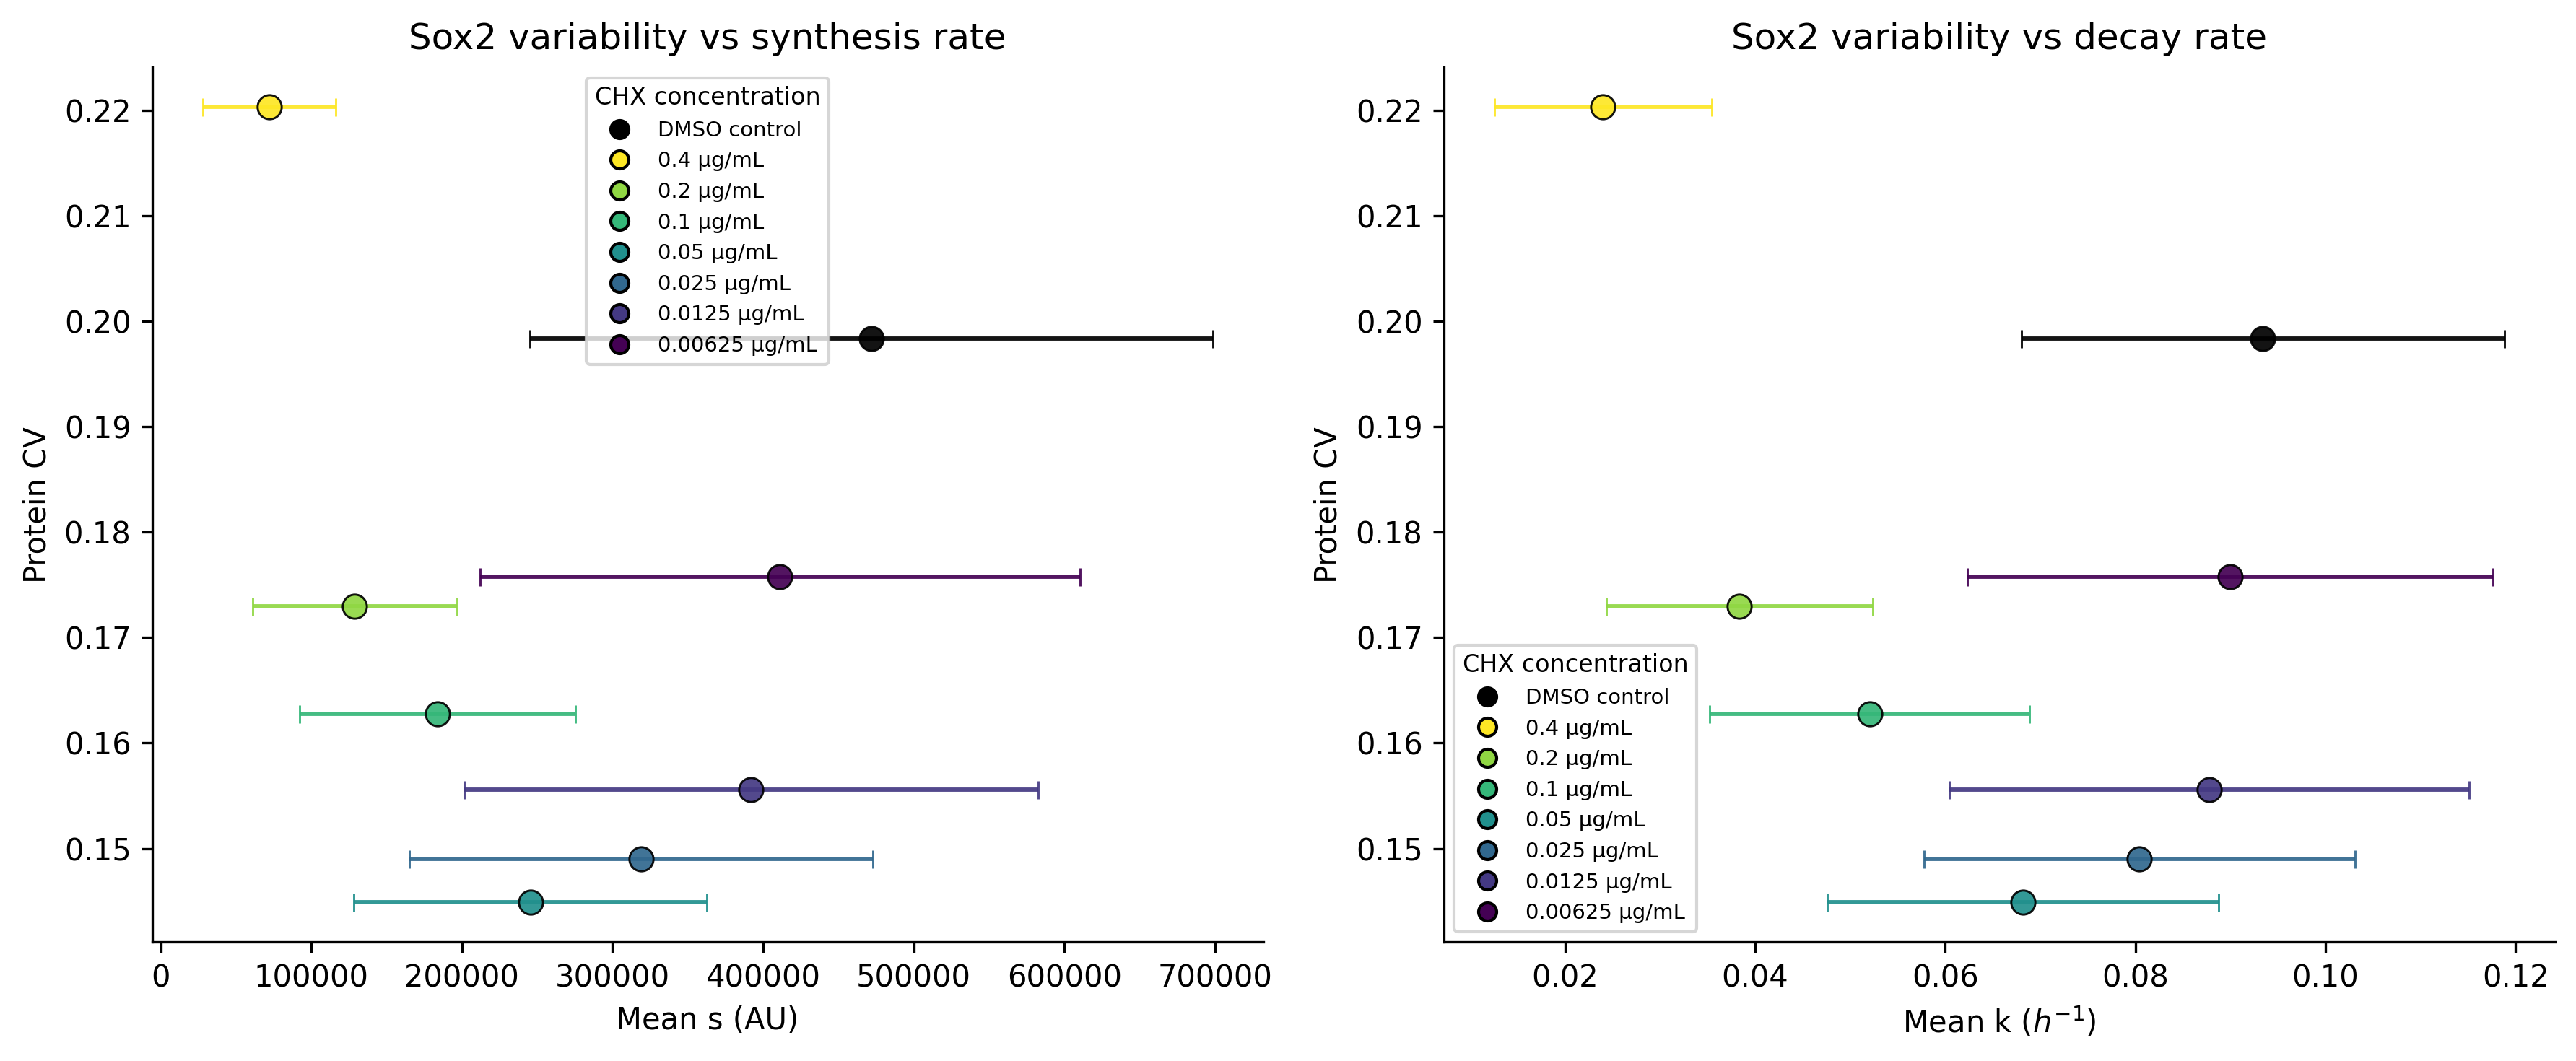

In [6]:
def _scatter_cv_vs_rate(ax, x_col, xerr_col, xlabel, title):
    """
    Scatter: mean CV (y) vs mean rate (x) with ±1 SD error bars.
    One dot per CHX condition, coloured by log-concentration.
    """
    for _, row in summary.iterrows():
        color = get_color(row["CHX_conc"])
        ax.errorbar(
            row[x_col], row["cv_mean_IF_DR"],
            xerr=row[xerr_col],
            fmt="o",
            markersize=8,
            color=color,
            ecolor=color,
            elinewidth=1.4,
            capsize=3,
            markeredgecolor="black",
            markeredgewidth=0.7,
            alpha=0.92,
            zorder=3,
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Protein CV")
    ax.set_title(title)
    ax.legend(
        handles=make_legend_handles(linestyle=""),
        title="CHX concentration",
        fontsize=7,
        title_fontsize=8,
        loc="best",
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=DPI)

_scatter_cv_vs_rate(
    axes[0],
    x_col="mean_s", xerr_col="std_s",
    xlabel="Mean s (AU)",
    title=f"{PROTEIN} variability vs synthesis rate",
)
_scatter_cv_vs_rate(
    axes[1],
    x_col="mean_k", xerr_col="std_k",
    xlabel=r"Mean k ($h^{-1}$)",
    title=f"{PROTEIN} variability vs decay rate",
)

plt.tight_layout()
plt.show()


## Effect of CHX on synthesis rate (s) and decay rate (k)

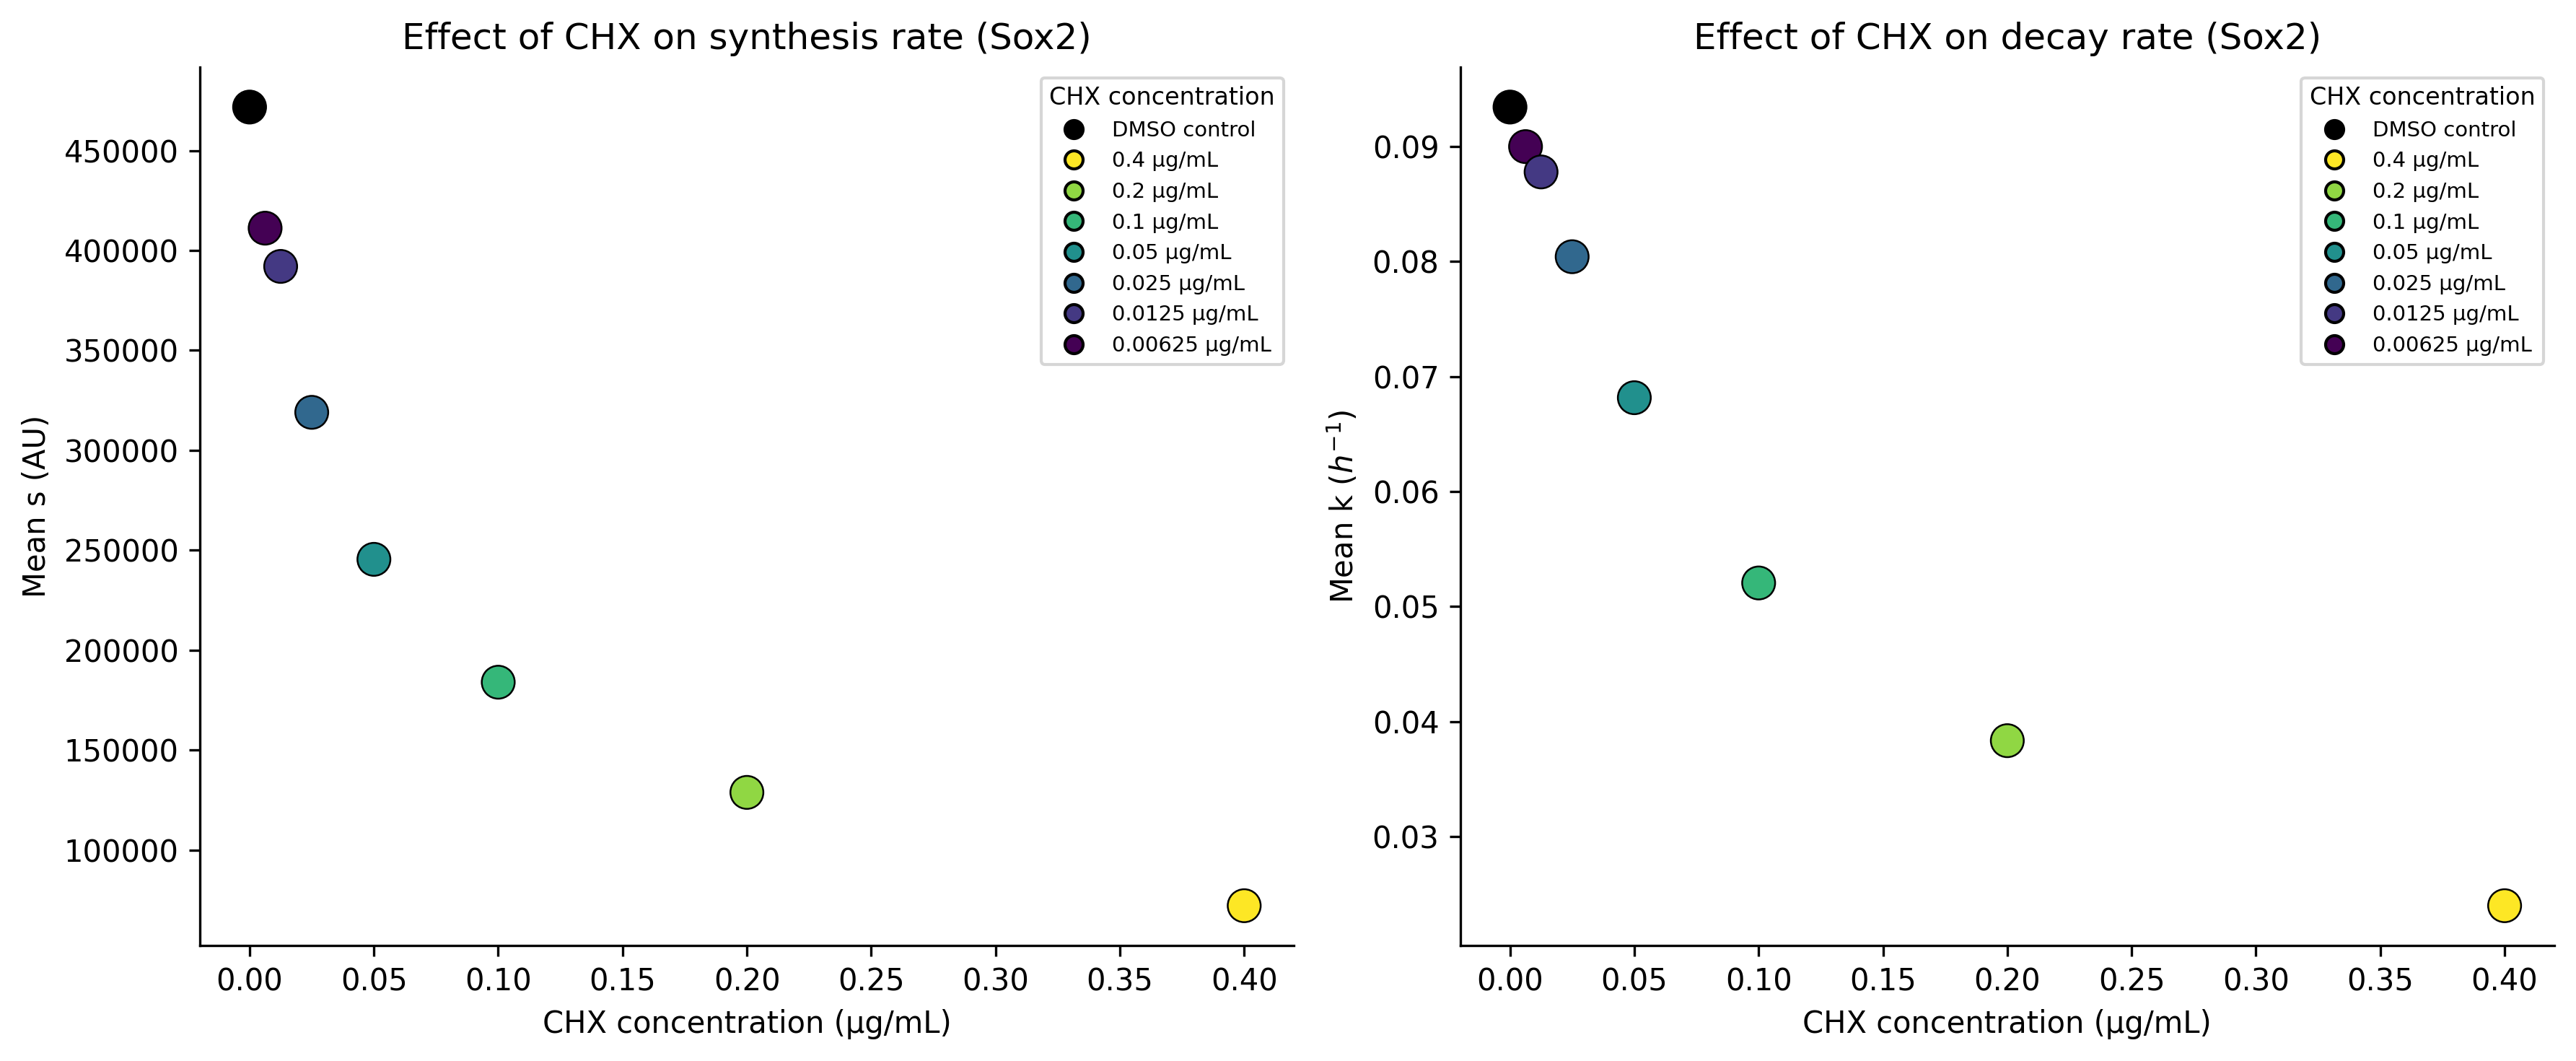

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=DPI)

for ax, y_col, y_label, title in [
    (axes[0], "mean_s", "Mean s (AU)",       f"Effect of CHX on synthesis rate ({PROTEIN})"),
    (axes[1], "mean_k", r"Mean k ($h^{-1}$)", f"Effect of CHX on decay rate ({PROTEIN})"),
]:
    point_colors = [get_color(c) for c in summary["CHX_conc"]]
    ax.scatter(
        summary["CHX_conc"], summary[y_col],
        s=120, c=point_colors,
        edgecolor="black", linewidth=0.6,
    )
    ax.set_xlabel("CHX concentration (μg/mL)")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend(
        handles=make_legend_handles(linestyle=""),
        title="CHX concentration",
        fontsize=7, title_fontsize=8, loc="best",
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


## Quantile analysis: protein CV vs s-quantile within each CHX condition

Cells in each CHX row are split into 5 quantile bins by synthesis rate *s*.
Each line traces CV vs mean-s across those bins.

In [9]:
rows_s = []

for r in ROWS:
    df_r = get_chx_condition_df(df_chx, r_num=r, c_num=CHX_COL)
    if len(df_r) < 20:
        continue

    df_r = df_r.copy()
    df_r[S_COL]  = pd.to_numeric(df_r[S_COL],  errors="coerce")
    df_r[Y_COL]  = pd.to_numeric(df_r[Y_COL],  errors="coerce")
    df_r = df_r.dropna(subset=[S_COL, Y_COL])

    df_r["q"] = pd.qcut(df_r[S_COL], q=5, labels=False, duplicates="drop")

    for q, sub in df_r.groupby("q"):
        rows_s.append({
            "r_num":    r,
            "CHX_conc": CHX_CONC[r],
            "quantile": int(q) + 1,
            "mean_s":   sub[S_COL].mean(),
            "std_s":    sub[S_COL].std(ddof=1),
            "cv":       cv_std_over_mean(sub[Y_COL]),
        })

summary_s = pd.DataFrame(rows_s)


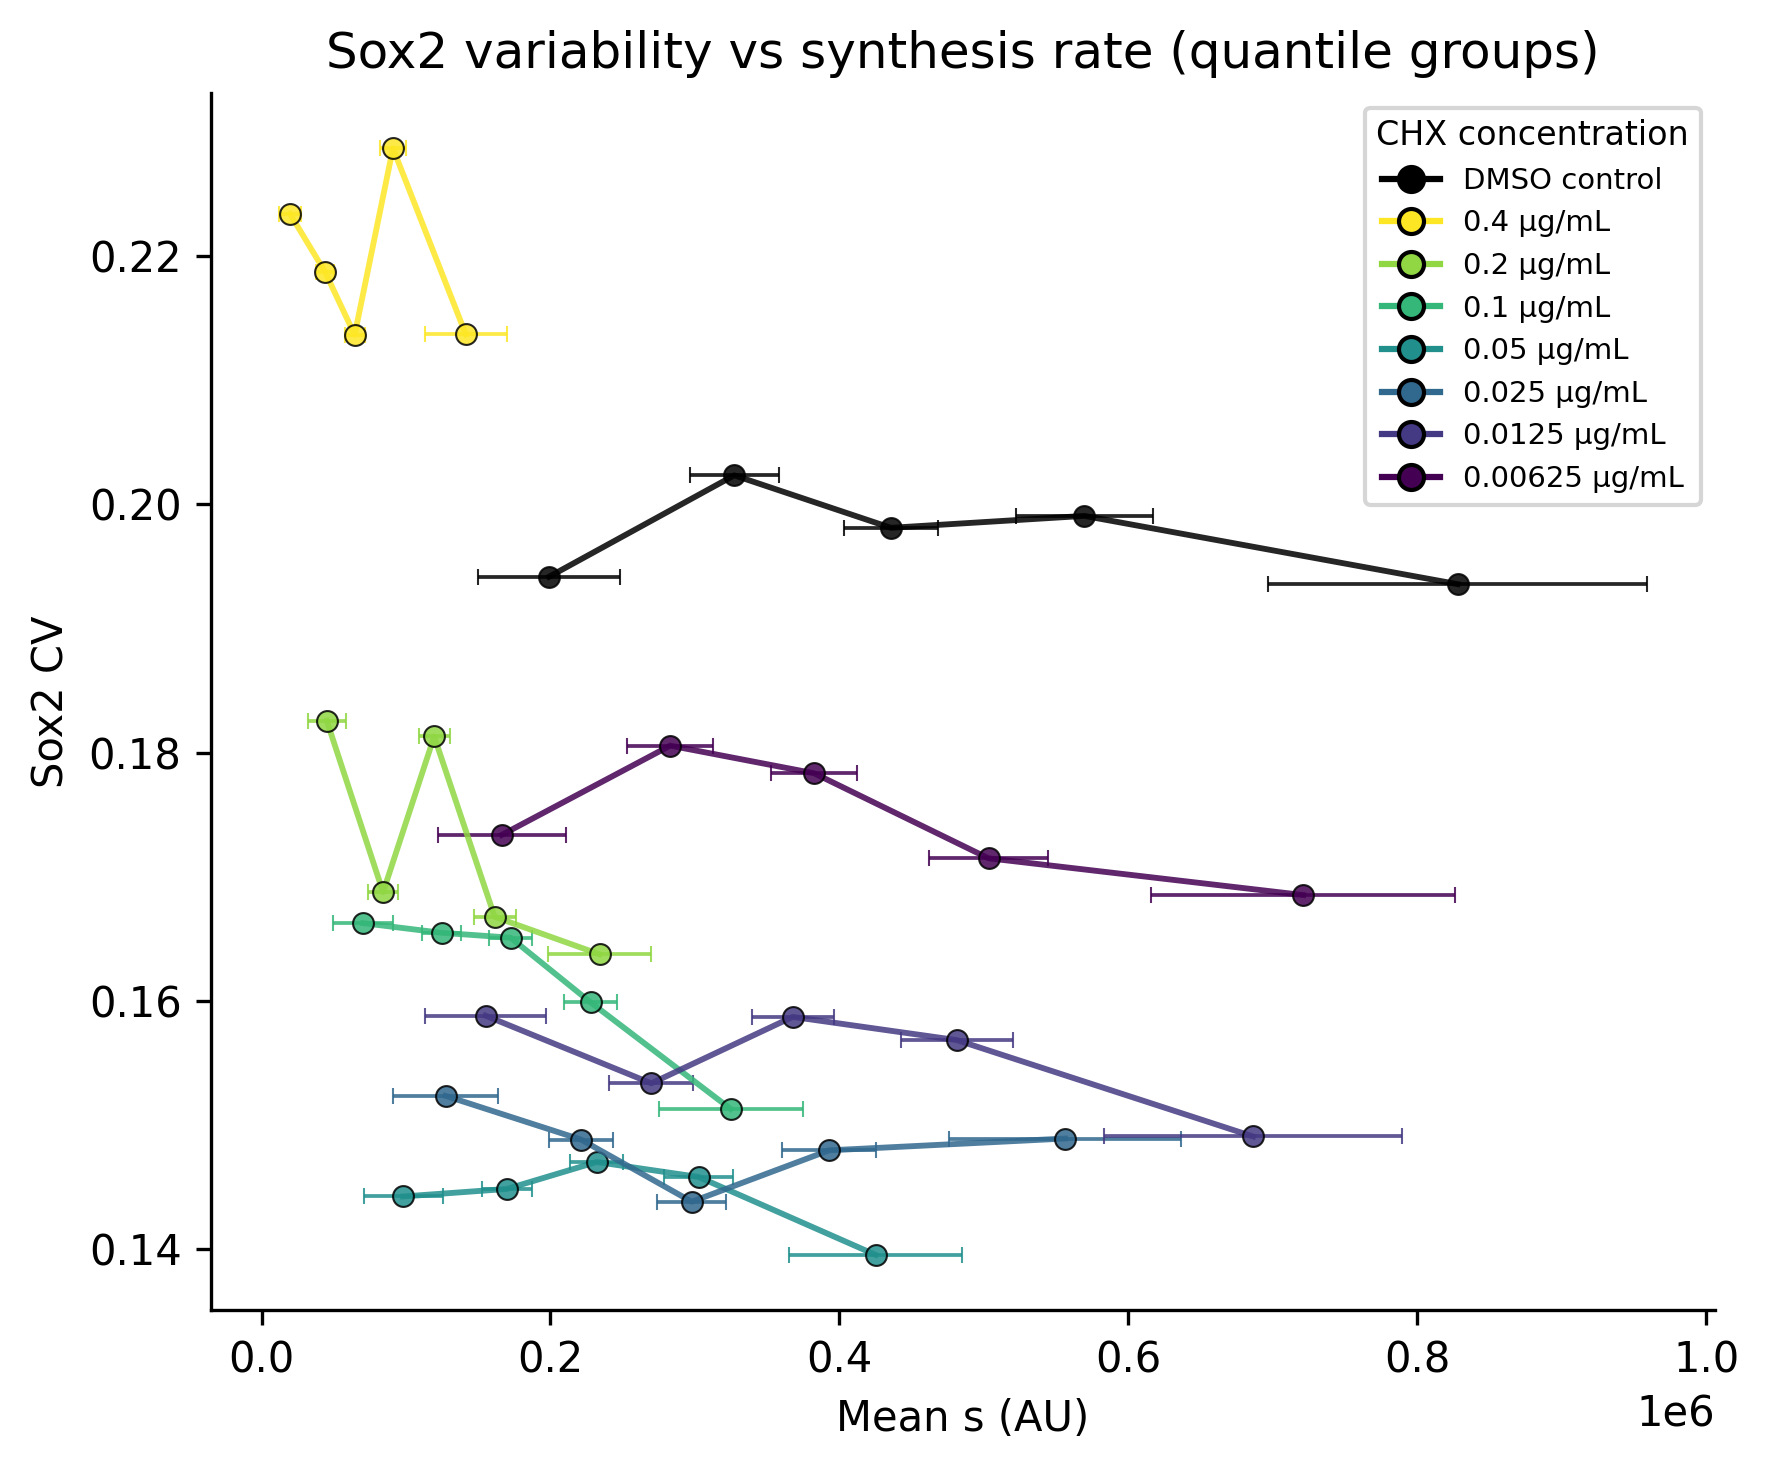

In [9]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=DPI)

for r in ROWS:
    sub = summary_s[summary_s["r_num"] == r]
    if sub.empty:
        continue

    color = get_color(CHX_CONC[r])

    # Horizontal error bars = SD of s within each quantile bin
    ax.errorbar(
        sub["mean_s"], sub["cv"],
        xerr=sub["std_s"],
        fmt="o-",
        markersize=5,
        color=color,
        ecolor=color,
        elinewidth=0.9,
        capsize=2,
        markeredgecolor="black",
        markeredgewidth=0.5,
        alpha=0.85,
        linewidth=1.4,
    )

ax.set_xlabel("Mean s (AU)")
ax.set_ylabel(f"{PROTEIN} CV")
ax.set_title(f"{PROTEIN} variability vs synthesis rate (quantile groups)")
ax.legend(
    handles=make_legend_handles(),
    title="CHX concentration",
    fontsize=7, title_fontsize=8, loc="best",
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


## Quantile analysis: protein CV vs k-quantile within each CHX condition

Same as above but binned by decay rate *k*.

In [10]:
rows_k = []

for r in ROWS:
    df_r = get_chx_condition_df(df_chx, r_num=r, c_num=CHX_COL)
    if len(df_r) < 20:
        continue

    df_r = df_r.copy()
    df_r[K_COL]  = pd.to_numeric(df_r[K_COL],  errors="coerce")
    df_r[Y_COL]  = pd.to_numeric(df_r[Y_COL],  errors="coerce")
    df_r = df_r.dropna(subset=[K_COL, Y_COL])

    df_r["q"] = pd.qcut(df_r[K_COL], q=5, labels=False, duplicates="drop")

    for q, sub in df_r.groupby("q"):
        rows_k.append({
            "r_num":    r,
            "CHX_conc": CHX_CONC[r],
            "quantile": int(q) + 1,
            "mean_k":   sub[K_COL].mean(),
            "std_k":    sub[K_COL].std(ddof=1),
            "cv":       cv_std_over_mean(sub[Y_COL]),
        })

summary_k = pd.DataFrame(rows_k)


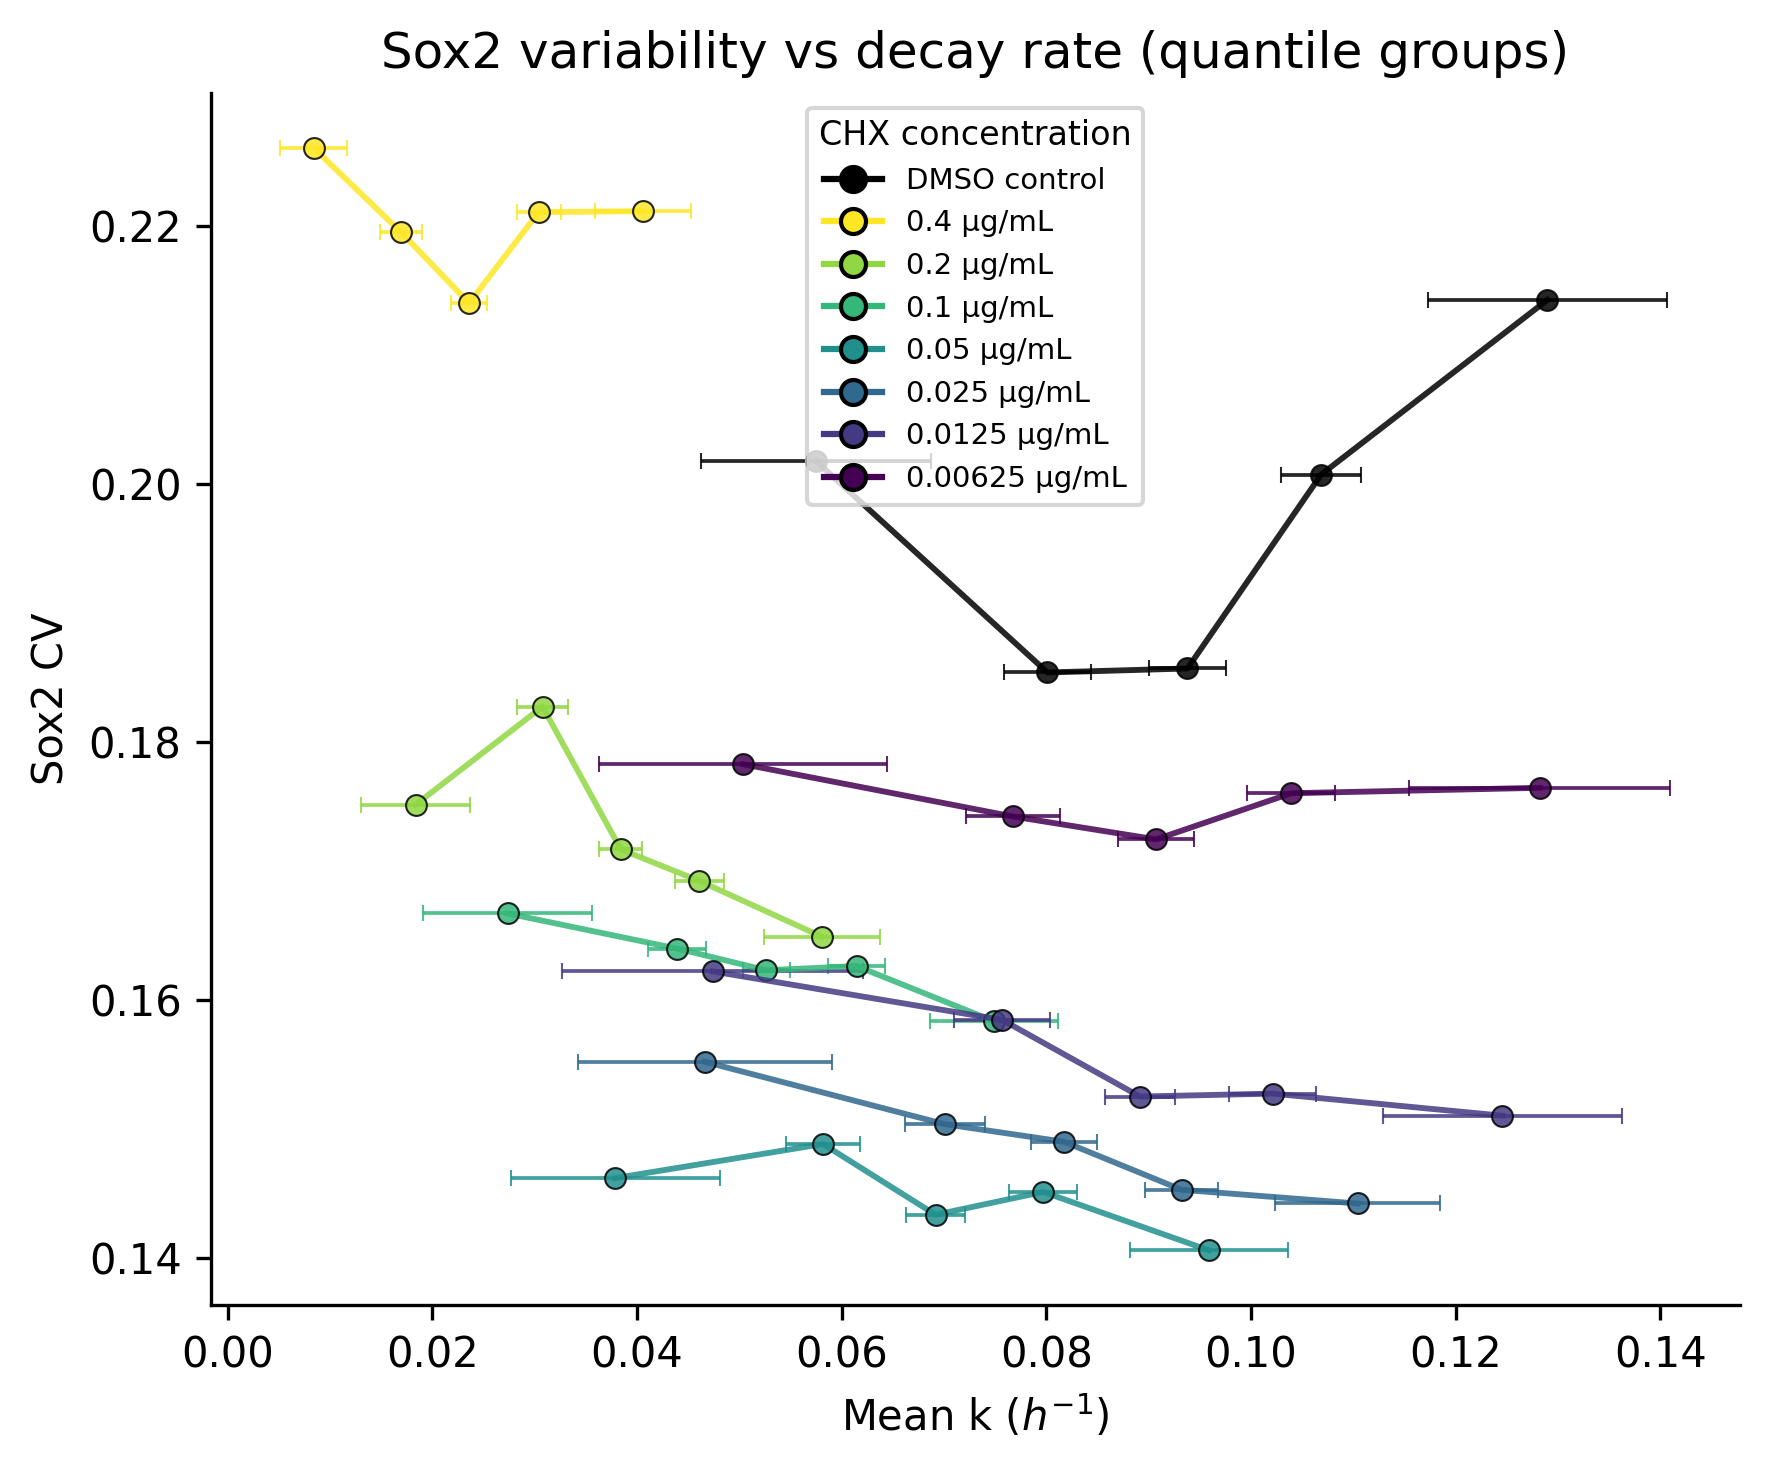

In [11]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=DPI)

for r in ROWS:
    sub = summary_k[summary_k["r_num"] == r]
    if sub.empty:
        continue

    color = get_color(CHX_CONC[r])

    # Horizontal error bars = SD of k within each quantile bin
    ax.errorbar(
        sub["mean_k"], sub["cv"],
        xerr=sub["std_k"],
        fmt="o-",
        markersize=5,
        color=color,
        ecolor=color,
        elinewidth=0.9,
        capsize=2,
        markeredgecolor="black",
        markeredgewidth=0.5,
        alpha=0.85,
        linewidth=1.4,
    )

ax.set_xlabel(r"Mean k ($h^{-1}$)")
ax.set_ylabel(f"{PROTEIN} CV")
ax.set_title(f"{PROTEIN} variability vs decay rate (quantile groups)")
ax.legend(
    handles=make_legend_handles(),
    title="CHX concentration",
    fontsize=7, title_fontsize=8, loc="best",
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


## Sliding-window CV vs k-quantile (continuous curves)

A fixed-mass sliding window sweeps along the k-rank axis (quantile space 0→1).
Each CHX condition produces one curve.

In [12]:
def sliding_k_quantile_cv(df, *, k_col=K_COL, y_col=Y_COL,
                           window_frac=WINDOW_FRAC, step_frac=STEP_FRAC,
                           window_n=WINDOW_N, step_n=STEP_N,
                           min_window_n=MIN_WINDOW_N):
    """
    Sort cells by k, slide a fixed-mass window, compute CV = std(y)/mean(y).
    Returns DataFrame with columns [q_center, k_median, cv].
    """
    df = df[[k_col, y_col]].apply(pd.to_numeric, errors="coerce").dropna()
    df = df.sort_values(k_col).reset_index(drop=True)
    n  = len(df)
    if n < min_window_n:
        return pd.DataFrame(columns=["q_center", "k_median", "cv"])

    w = int(window_n) if window_n else max(min_window_n, int(round(window_frac * n)))
    s = int(step_n)   if step_n   else max(1, int(round(step_frac * n)))

    records = []
    for start in range(0, n - w + 1, s):
        end  = start + w
        win  = df.iloc[start:end]
        y    = win[y_col].values
        mu   = float(np.nanmean(y))
        if mu == 0 or np.isnan(mu):
            continue
        cv   = float(np.nanstd(y, ddof=1)) / mu
        records.append({
            "q_center": (start + end / 2) / n,   # center index → quantile
            "k_median": float(win[k_col].median()),
            "cv":       cv,
        })

    return pd.DataFrame(records)


def interp_to_grid(curve_df, x_grid):
    if curve_df.empty:
        return np.full(len(x_grid), np.nan)
    x_unique = np.sort(curve_df["q_center"].unique())
    y_unique  = curve_df.groupby("q_center")["cv"].mean().loc[x_unique].values
    if len(x_unique) < 2:
        return np.full(len(x_grid), np.nan)
    return np.interp(x_grid, x_unique, y_unique, left=np.nan, right=np.nan)


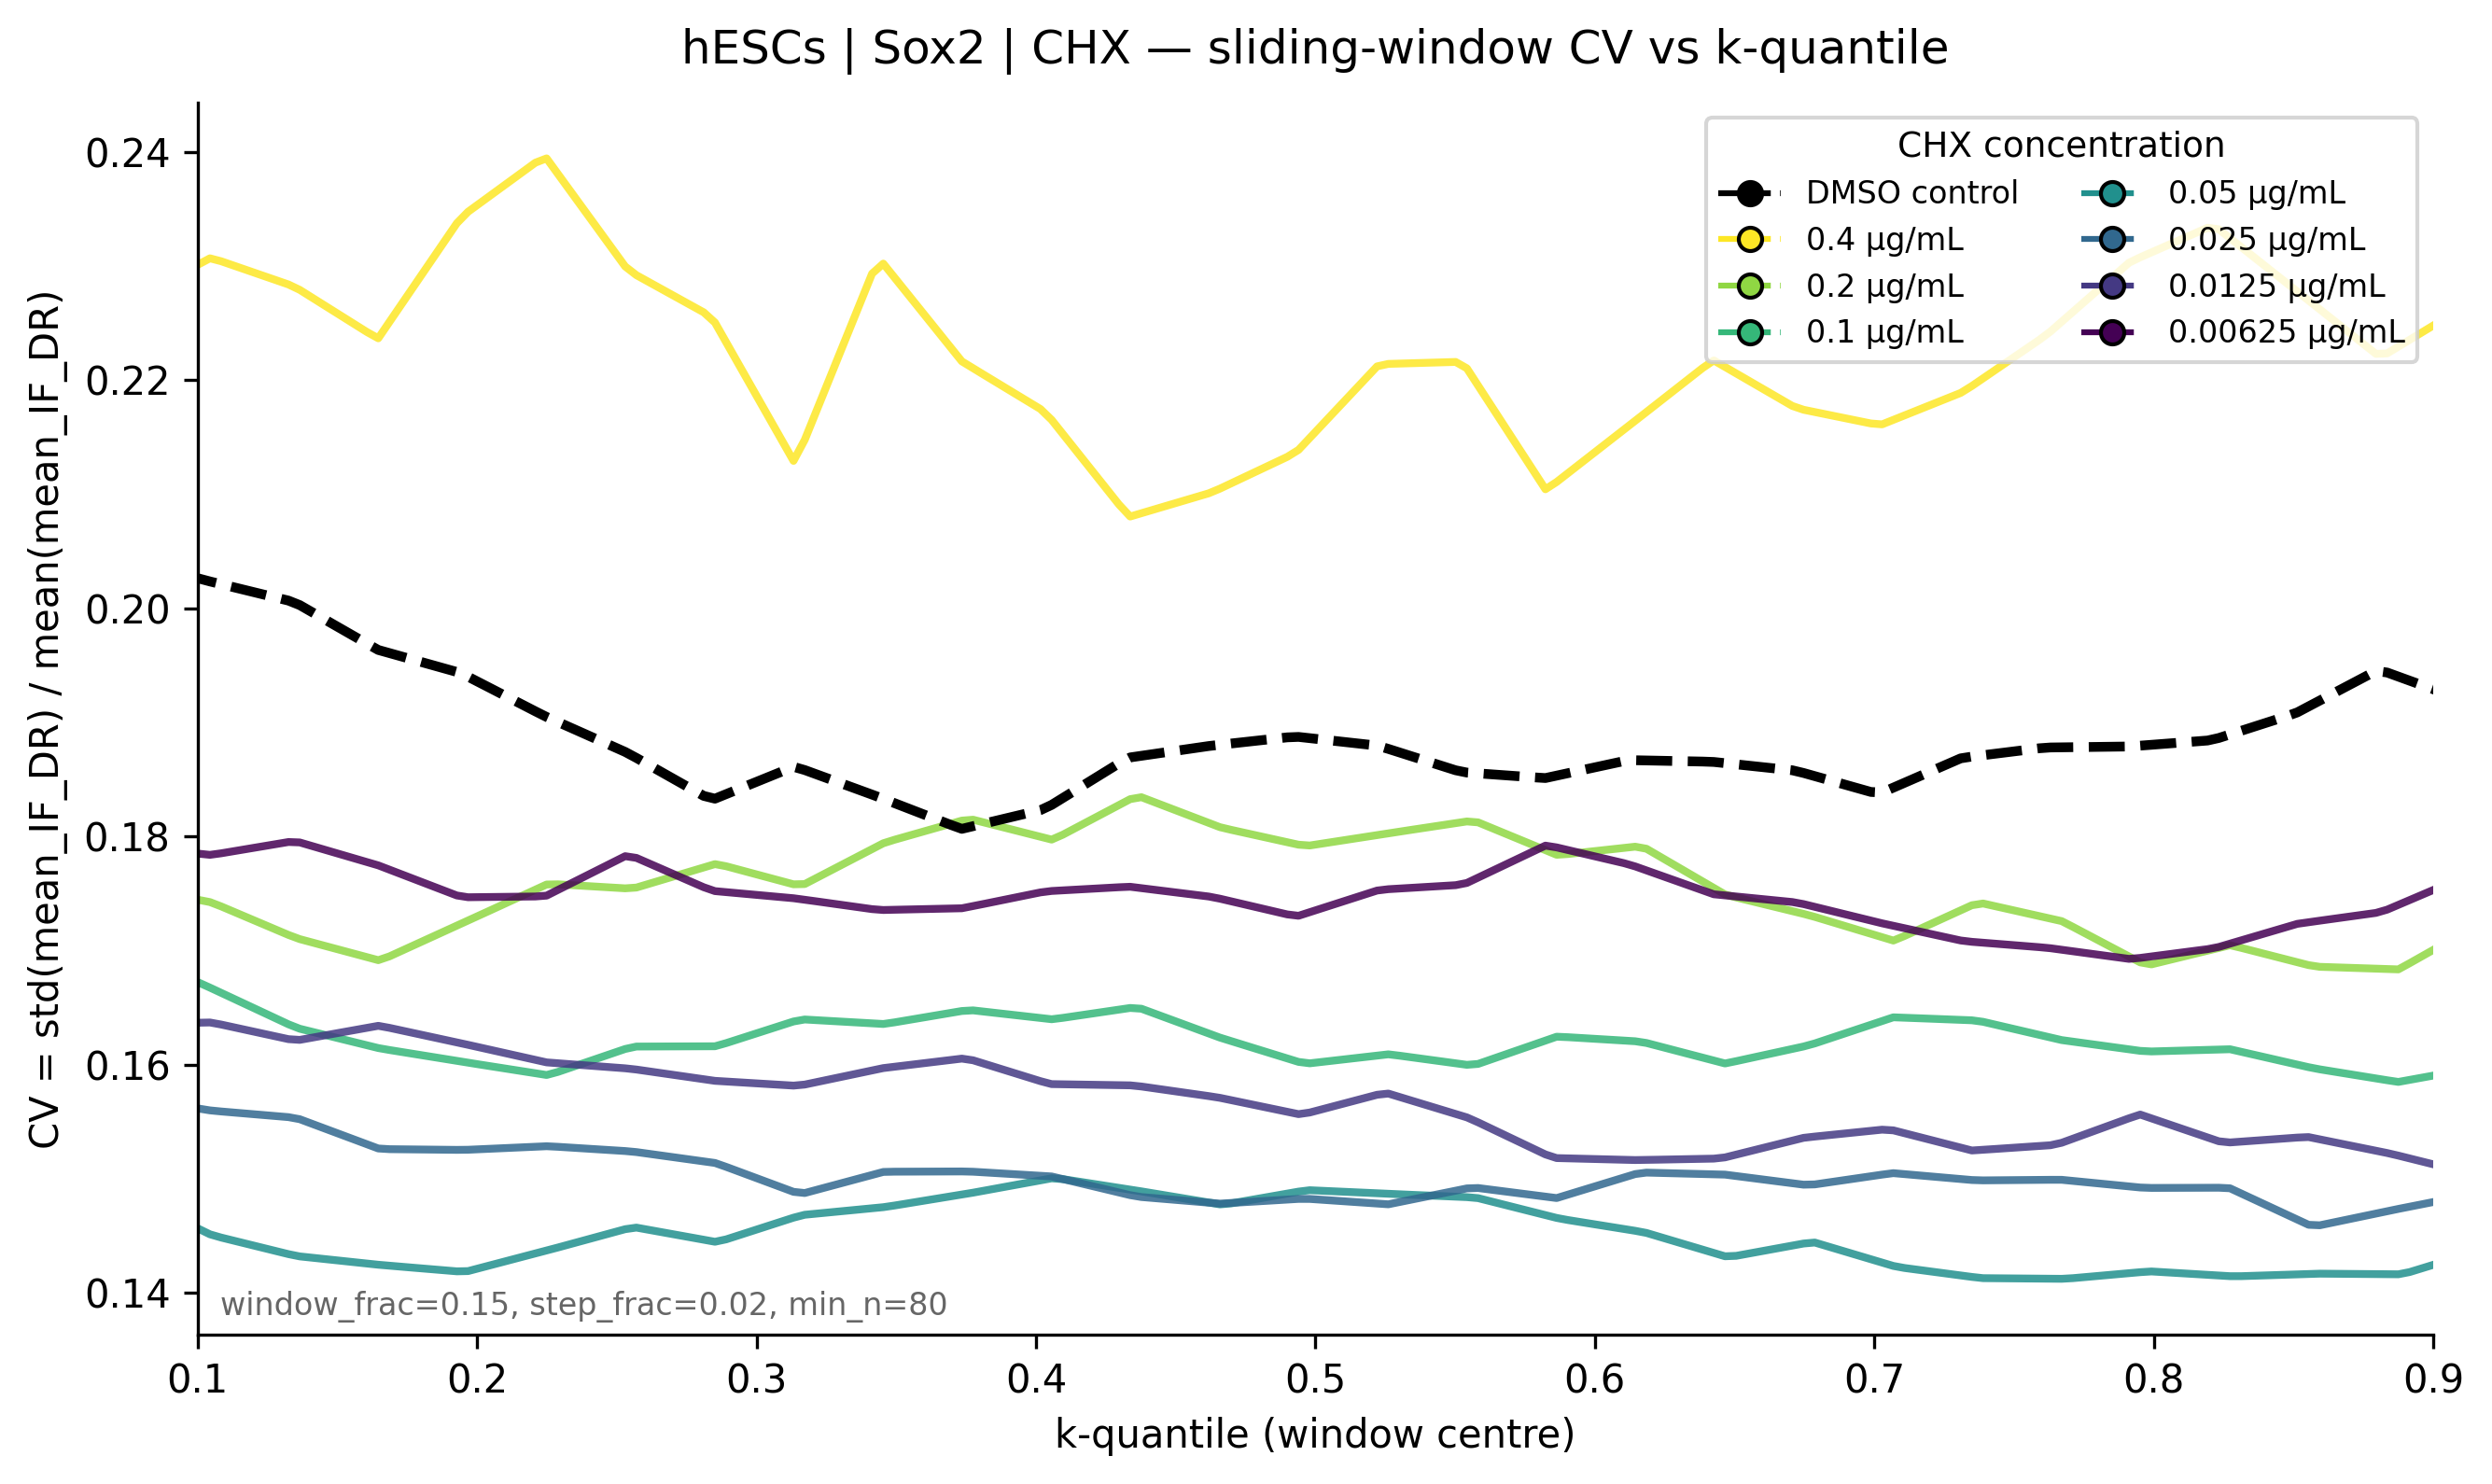

In [13]:
x_grid = np.linspace(0.0, 1.0, X_GRID_N)

fig, ax = plt.subplots(figsize=(9.0, 5.4), dpi=DPI)

# DMSO — dashed dark line
df_dmso = get_chx_condition_df(df_chx, r_num=DMSO_ROW, c_num=CHX_COL)
y_dmso  = interp_to_grid(sliding_k_quantile_cv(df_dmso), x_grid)
ax.plot(x_grid, y_dmso, label="DMSO control",
        color="black", lw=2.5, ls="--", zorder=5)

# CHX rows (R02 highest → R08 lowest)
for r in [r for r in ROWS if r != DMSO_ROW]:
    df_r  = get_chx_condition_df(df_chx, r_num=r, c_num=CHX_COL)
    y     = interp_to_grid(sliding_k_quantile_cv(df_r), x_grid)
    if np.all(np.isnan(y)):
        print(f"⚠️ empty curve: R{r:02d}")
        continue
    color = get_color(CHX_CONC[r])
    label = f"{CHX_CONC[r]:g} μg/mL"
    ax.plot(x_grid, y, label=label, color=color, lw=2.0, alpha=0.85)

ax.set_xlim(0.1, 0.9)
ax.set_xlabel("k-quantile (window centre)")
ax.set_ylabel(f"CV = std({Y_COL}) / mean({Y_COL})")
ax.set_title(f"{CELL_LINE} | {PROTEIN} | CHX — sliding-window CV vs k-quantile",
             fontsize=12, pad=10)

ax.legend(
    handles=make_legend_handles(linestyle="--"),
    title="CHX concentration",
    fontsize=8, title_fontsize=9, ncol=2, frameon=True, loc="upper right",
)

ax.text(0.01, 0.01,
        f"window_frac={WINDOW_FRAC}, step_frac={STEP_FRAC}, min_n={MIN_WINDOW_N}",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=8, color="0.4")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


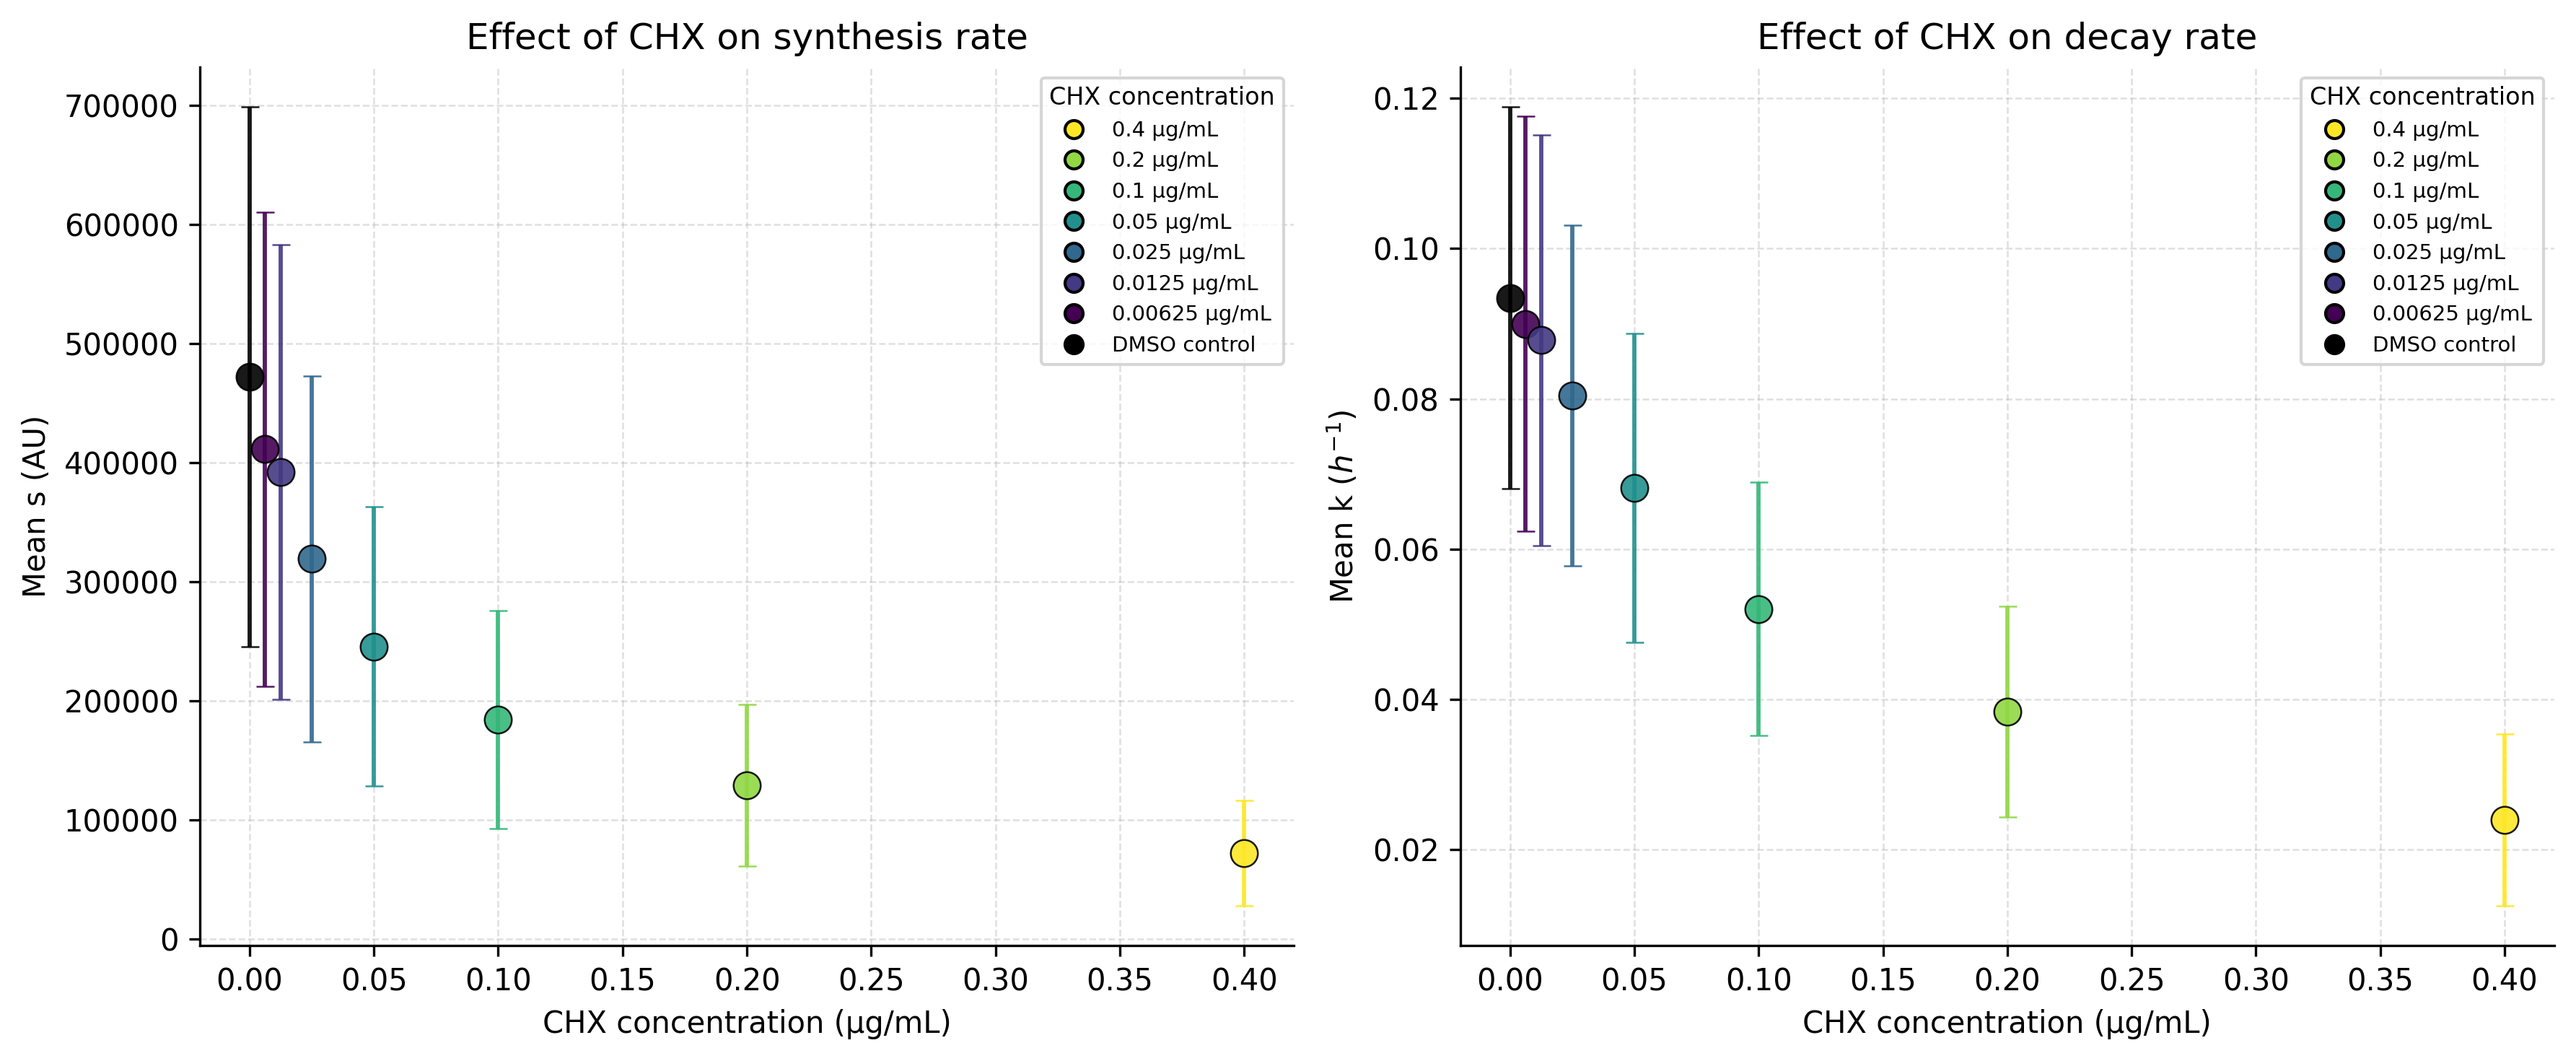

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=DPI)

for ax, y_col, y_err, y_label, title in [
    (axes[0], "mean_s", "std_s", "Mean s (AU)",        f"Effect of CHX on synthesis rate"),
    (axes[1], "mean_k", "std_k", r"Mean k ($h^{-1}$)", f"Effect of CHX on decay rate"),
]:
    for _, row in summary.iterrows():
        color = get_color(row["CHX_conc"])

        ax.errorbar(
            row["CHX_conc"], row[y_col],
            yerr=row[y_err],          # vertical SD bars
            fmt="o",
            markersize=9,
            color=color,
            ecolor=color,
            elinewidth=1.4,
            capsize=3,
            markeredgecolor="black",
            markeredgewidth=0.6,
            alpha=0.9,
            zorder=3,
        )

    ax.set_xlabel("CHX concentration (μg/mL)")
    ax.set_ylabel(y_label)
    ax.set_title(title)

    ax.legend(
        handles=make_legend_handles(linestyle=""),
        title="CHX concentration",
        fontsize=7,
        title_fontsize=8,
        loc="best",
    )

    ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

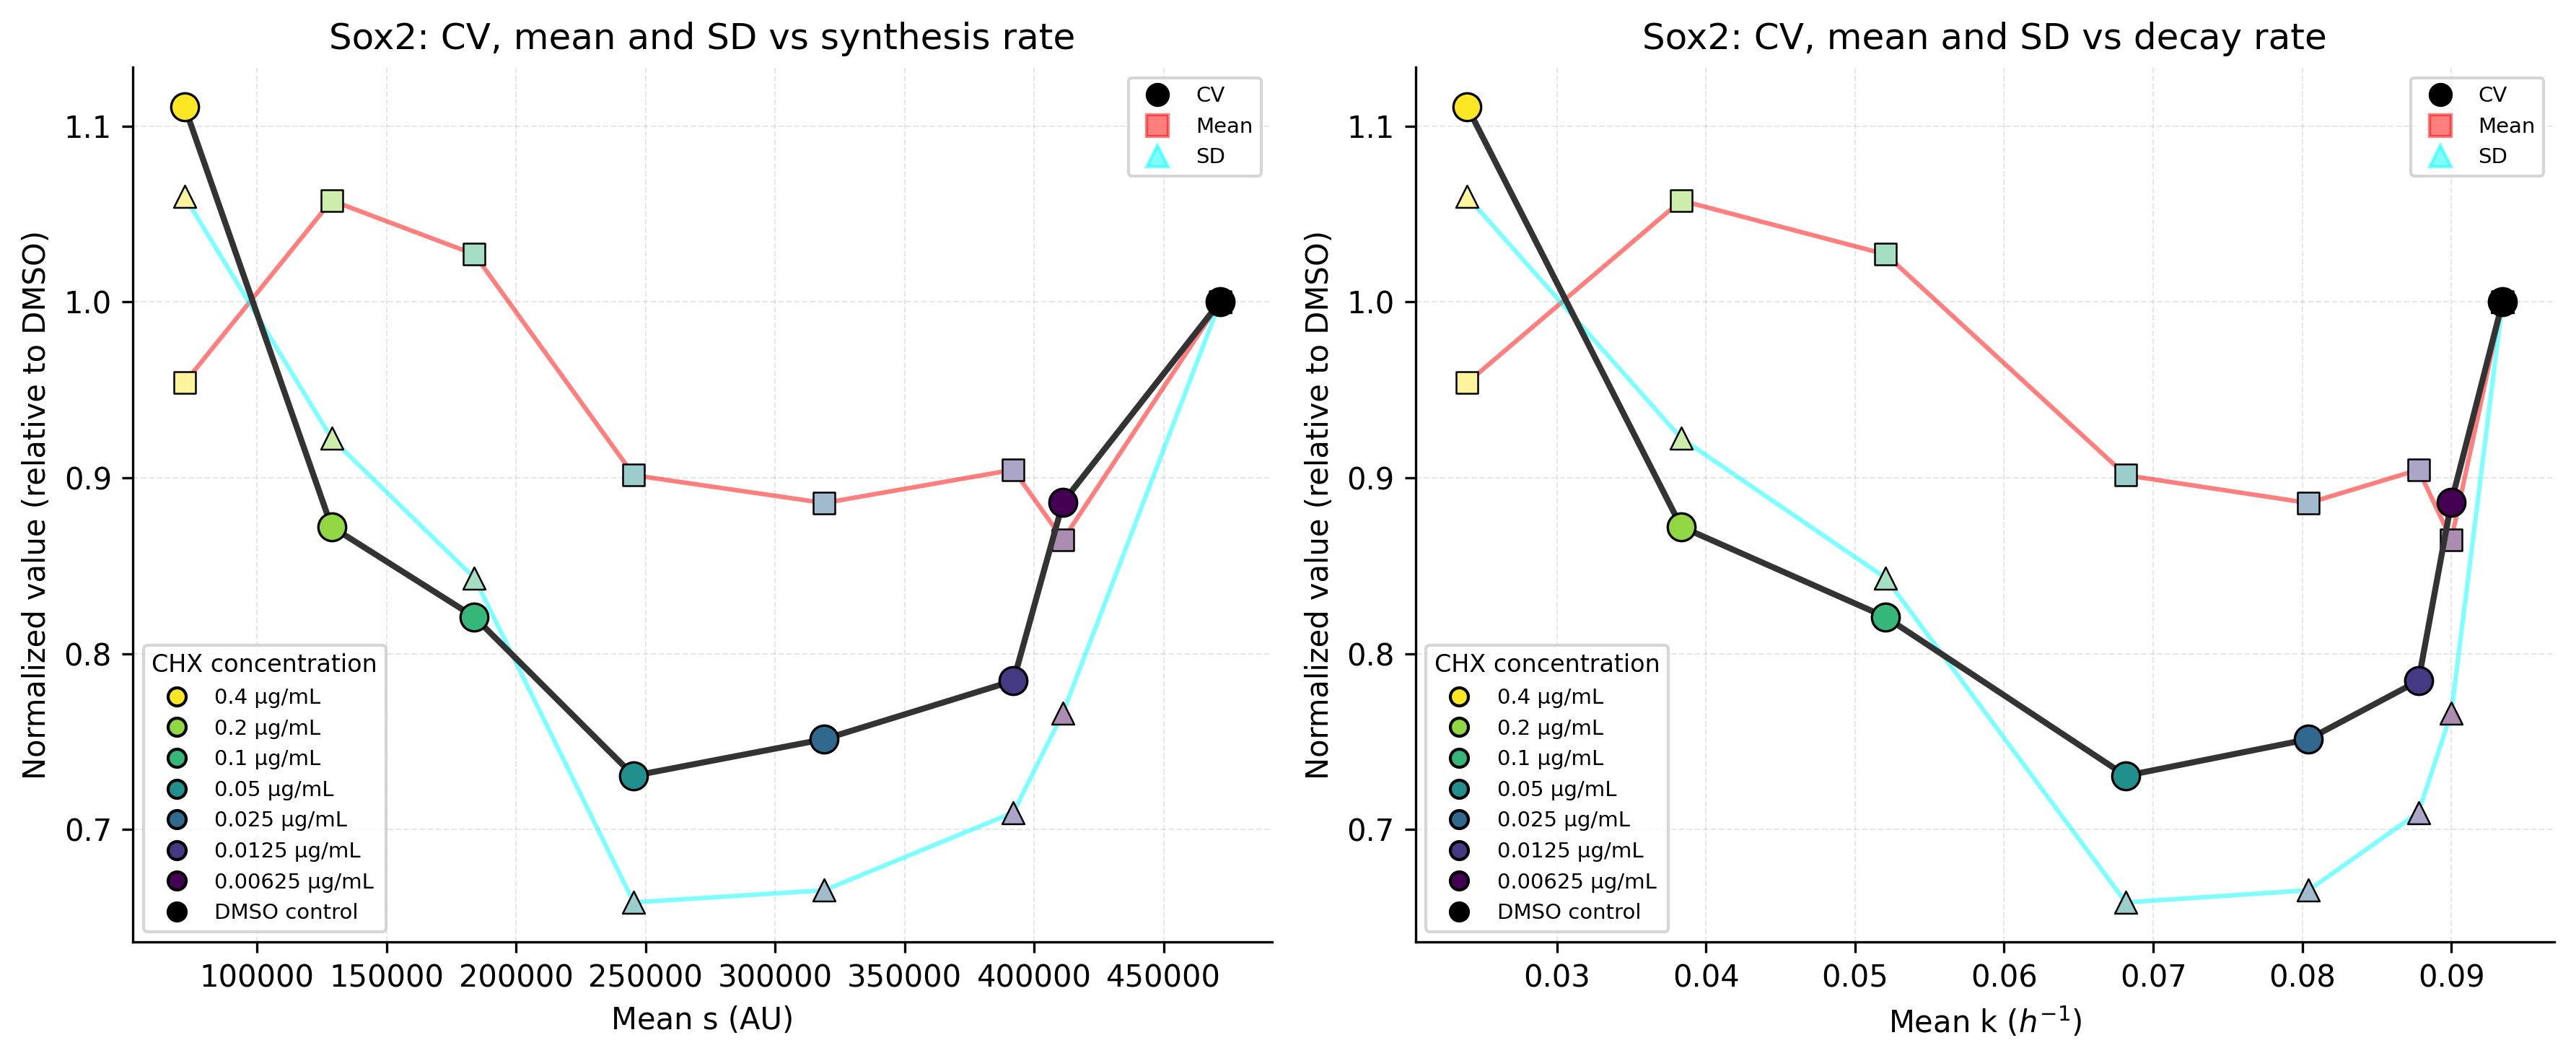

In [90]:
# DMSO normalization
dmso = summary.loc[summary["CHX_conc"] == 0].iloc[0]

cv_ref   = dmso["cv_mean_IF_DR"]
mean_ref = dmso["mean_IF_DR"]
std_ref  = dmso["std_IF_DR"]

import matplotlib.colors as mc

def lighten(color, amount=0.55):
    """
    Blend a color with white.
    amount=0 -> original color
    amount=1 -> white
    """
    c = mc.to_rgb(color)
    white = (1, 1, 1)
    return tuple((1 - amount) * x + amount * w for x, w in zip(c, white))

def _scatter_cv_vs_rate(ax, x_col, xlabel, title):

    df = summary.sort_values(x_col).copy()
    x = df[x_col].values

    cv_norm   = df["cv_mean_IF_DR"] / cv_ref
    mean_norm = df["mean_IF_DR"] / mean_ref
    std_norm  = df["std_IF_DR"] / std_ref

    # -----------------------------------
    # LINES (no alpha → no ghosting issues)
    # -----------------------------------
    ax.plot(x, cv_norm,   color="0.2", lw=2, zorder=9)
    ax.plot(x, mean_norm, color="red", alpha=0.5, lw=1.5, zorder=2)
    ax.plot(x, std_norm,  color="cyan", alpha=0.5, lw=1.5, zorder=2)

    # -----------------------------------
    # MARKERS (lightened CHX colors)
    # -----------------------------------
    for _, row in df.iterrows():

        base_color = get_color(row["CHX_conc"])
        light_color = lighten(base_color, amount=0.55)

        # CV (strong, original color)
        ax.scatter(
            row[x_col],
            row["cv_mean_IF_DR"] / cv_ref,
            marker="o",
            s=85,
            facecolors=base_color,
            edgecolors="black",
            linewidth=0.8,
            zorder=10,
        )

        # Mean (light CHX color)
        ax.scatter(
            row[x_col],
            row["mean_IF_DR"] / mean_ref,
            marker="s",
            s=55,
            facecolors=light_color,
            edgecolors="black",
            linewidth=0.6,
            zorder=7,
        )

        # SD (light CHX color)
        ax.scatter(
            row[x_col],
            row["std_IF_DR"] / std_ref,
            marker="^",
            s=55,
            facecolors=light_color,
            edgecolors="black",
            linewidth=0.6,
            zorder=6,
        )

    # -----------------------------------
    # AXES STYLE
    # -----------------------------------
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Normalized value (relative to DMSO)")
    ax.set_title(title)

    ax.grid(True, ls="--", lw=0.5, alpha=0.3)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # -----------------------------------
    # LEGENDS
    # -----------------------------------
    from matplotlib.lines import Line2D

    color_legend = make_legend_handles(linestyle="")

    metric_legend = [
        Line2D([0], [0], marker="o", color="black", linestyle="None",
               markersize=7, label="CV"),
        Line2D([0], [0], marker="s", color="red", alpha=0.5, linestyle="None",
               markersize=7, label="Mean"),
        Line2D([0], [0], marker="^", color="cyan", alpha=0.5, linestyle="None",
               markersize=7, label="SD"),
    ]

    leg1 = ax.legend(
        handles=color_legend,
        title="CHX concentration",
        fontsize=7,
        title_fontsize=8,
        loc="lower left",
    )

    leg2 = ax.legend(
        handles=metric_legend,
        title="",
        fontsize=7,
        title_fontsize=8,
        loc="upper right",
    )

    ax.add_artist(leg1)


fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=DPI)

_scatter_cv_vs_rate(
    axes[0],
    x_col="mean_s",
    xlabel="Mean s (AU)",
    title=f"{PROTEIN}: CV, mean and SD vs synthesis rate",
)

_scatter_cv_vs_rate(
    axes[1],
    x_col="mean_k",
    xlabel=r"Mean k ($h^{-1}$)",
    title=f"{PROTEIN}: CV, mean and SD vs decay rate",
)

plt.tight_layout()
plt.show()

In [80]:
rows_out = []

for r in ROWS:
    df_r = get_chx_condition_df(df_chx, r_num=r, c_num=CHX_COL)

    if df_r.empty:
        rows_out.append(dict(
            r_num=r, CHX_conc=CHX_CONC[r],
            mean_s=np.nan, std_s=np.nan,
            mean_k=np.nan, std_k=np.nan,
            mean_IF_DR=np.nan, std_IF_DR=np.nan,
            cv_mean_IF_DR=np.nan,
            mean_sum_IF_DR=np.nan, mean_area_TL=np.nan,
            n=0
        ))
        continue

    s_vals = pd.to_numeric(df_r[S_COL], errors="coerce").dropna()
    k_vals = pd.to_numeric(df_r[K_COL], errors="coerce").dropna()
    y_vals = pd.to_numeric(df_r[Y_COL], errors="coerce").dropna()
    
    # Extract sum_IF_DR and area_TL from df_r
    sum_if_vals = pd.to_numeric(df_r["sum_IF_DR"], errors="coerce").dropna()
    p_tot_vals = pd.to_numeric(df_r["P_tot"], errors="coerce").dropna()
    area_tl_vals = pd.to_numeric(df_r["area_TL"], errors="coerce").dropna()

    rows_out.append(dict(
        r_num           = r,
        CHX_conc        = CHX_CONC[r],
        mean_s          = float(s_vals.mean())            if len(s_vals) else np.nan,
        std_s           = float(s_vals.std(ddof=1))       if len(s_vals) >= 2 else np.nan,
        mean_k          = float(k_vals.mean())            if len(k_vals) else np.nan,
        std_k           = float(k_vals.std(ddof=1))       if len(k_vals) >= 2 else np.nan,
        mean_IF_DR      = float(y_vals.mean())            if len(y_vals) else np.nan,
        std_IF_DR       = float(y_vals.std(ddof=1))       if len(y_vals) >= 2 else np.nan,
        cv_mean_IF_DR   = cv_std_over_mean(y_vals),
        mean_sum_IF_DR  = float(sum_if_vals.mean())       if len(sum_if_vals) else np.nan,
        mean_area_TL    = float(area_tl_vals.mean())       if len(area_tl_vals) else np.nan,
        mean_volume     = float(np.mean(area_tl_vals**(3/2) * 4 / (3 * np.sqrt(np.pi)))) if len(area_tl_vals) else np.nan,
        mean_P_tot      = float(p_tot_vals.mean())        if len(p_tot_vals) else np.nan,
        n               = len(y_vals),
    ))

summary = (
    pd.DataFrame(rows_out)
    .sort_values("CHX_conc")
    .reset_index(drop=True)
)

display(summary)

,r_num,CHX_conc,mean_s,std_s,mean_k,std_k,mean_IF_DR,std_IF_DR,cv_mean_IF_DR,mean_sum_IF_DR,mean_area_TL,mean_volume,mean_P_tot,n
0,1,0.00000,471783.219345,226657.209744,0.093428,0.025391,8722.311168,1729.870145,0.198327,5.008134e+06,526.839571,9434.561521,5.034437e+06,3821
1,8,0.00625,411177.894910,199133.687185,0.089990,0.027624,7543.153374,1325.648820,0.175742,4.267661e+06,524.950409,9371.789996,4.639384e+06,5626
2,7,0.01250,392036.762450,190686.580789,0.087787,0.027364,7889.803538,1227.616621,0.155595,4.381343e+06,511.770545,9017.723439,4.548604e+06,5500
3,6,0.02500,319012.865439,153855.628131,0.080417,0.022674,7724.907683,1151.100210,0.149012,4.254427e+06,482.453043,8249.345335,3.997544e+06,5686
4,5,0.05000,245446.757513,117281.518084,0.068159,0.020573,7862.587113,1139.168967,0.144885,4.145783e+06,455.049458,7541.413604,3.648016e+06,5075
5,4,0.10000,183959.020825,91626.670629,0.052053,0.016818,8958.267568,1458.307706,0.162789,4.313691e+06,436.629313,7063.607012,3.561978e+06,3739
6,3,0.20000,128811.724810,67927.299297,0.038342,0.014017,9225.064257,1595.693547,0.172974,4.205543e+06,408.287171,6395.838541,3.389037e+06,3040
7,2,0.40000,72108.985704,44254.827425,0.023994,0.011444,8321.517797,1833.376884,0.220318,3.509938e+06,388.484778,5919.290916,3.004096e+06,854


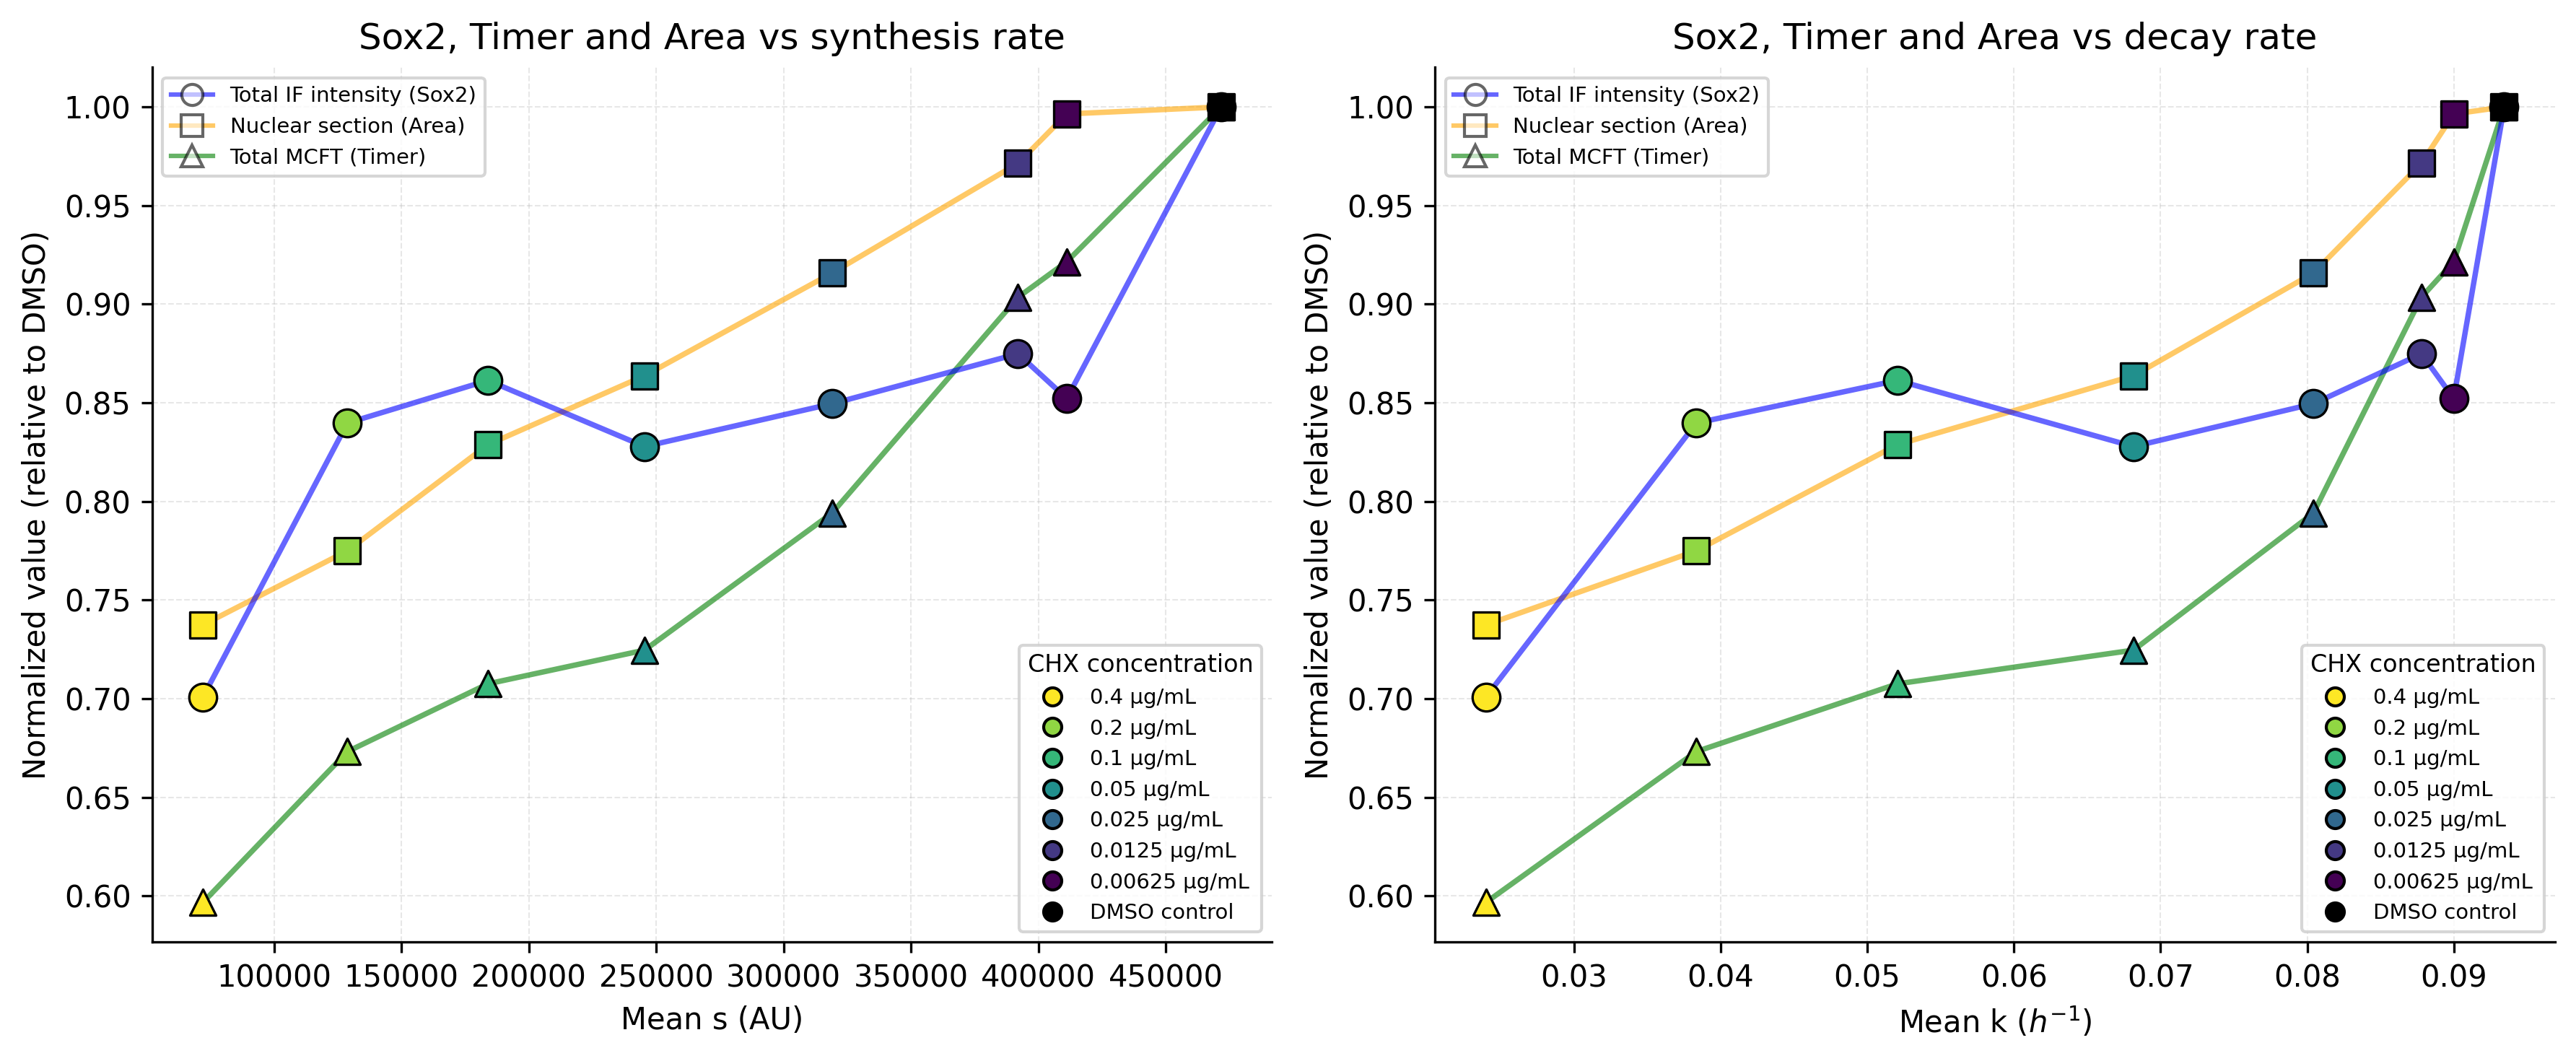

In [91]:
# DMSO normalization references
dmso = summary.loc[summary["CHX_conc"] == 0].iloc[0]
sum_IF_ref  = dmso["mean_sum_IF_DR"]
area_TL_ref = dmso["mean_area_TL"]
p_tot_ref   = dmso["mean_P_tot"]

def _scatter_metrics_vs_rate(ax, x_col, xlabel, title):
    df = summary.sort_values(x_col).copy()
    x = df[x_col].values

    # Normalize metrics relative to DMSO
    sum_IF_norm  = df["mean_sum_IF_DR"] / sum_IF_ref
    area_TL_norm = df["mean_area_TL"] / area_TL_ref
    p_tot_norm   = df["mean_P_tot"] / p_tot_ref

    # -----------------------------------
    # LINES (Connecting each series with a distinct color)
    # -----------------------------------
    ax.plot(x, sum_IF_norm,  color="blue", alpha=0.6, lw=1.8, zorder=3)
    ax.plot(x, area_TL_norm, color="orange", alpha=0.6, lw=1.8, zorder=2)
    ax.plot(x, p_tot_norm, color="green", alpha=0.6, lw=1.8, zorder=2)

    # -----------------------------------
    # MARKERS (Colors reflect CHX concentration)
    # -----------------------------------
    for _, row in df.iterrows():
        base_color = get_color(row["CHX_conc"])

        # sum_IF_DR (Circle marker)
        ax.scatter(
            row[x_col],
            row["mean_sum_IF_DR"] / sum_IF_ref,
            marker="o",
            s=85,
            facecolors=base_color,
            edgecolors="black",
            linewidth=0.8,
            zorder=10,
        )

        # area_TL (Square marker)
        ax.scatter(
            row[x_col],
            row["mean_area_TL"] / area_TL_ref,
            marker="s",
            s=75,
            facecolors=base_color,
            edgecolors="black",
            linewidth=0.8,
            zorder=10,
        )

        # P_tot (Triangle marker)
        ax.scatter(
            row[x_col],
            row["mean_P_tot"] / p_tot_ref,
            marker="^",
            s=75,
            facecolors=base_color,
            edgecolors="black",
            linewidth=0.8,
            zorder=10,
        )

    # -----------------------------------
    # AXES STYLE
    # -----------------------------------
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Normalized value (relative to DMSO)")
    ax.set_title(title)

    ax.grid(True, ls="--", lw=0.5, alpha=0.3)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # -----------------------------------
    # LEGENDS
    # -----------------------------------
    from matplotlib.lines import Line2D

    # CHX Concentration Legend
    color_legend = make_legend_handles(linestyle="")

    # Metrics Legend (Neutral white facecolor to focus on shape and line color)
    metric_legend = [
        Line2D([0], [0], marker="o", color="blue", alpha=0.6, linestyle="-",
               markersize=7, label="Total IF intensity (Sox2)", markerfacecolor="white", markeredgecolor="black", zorder=10),
        Line2D([0], [0], marker="s", color="orange", alpha=0.6, linestyle="-",
               markersize=7, label="Nuclear section (Area)", markerfacecolor="white", markeredgecolor="black", zorder=10),
        Line2D([0], [0], marker="^", color="green", alpha=0.6, linestyle="-",
               markersize=7, label="Total MCFT (Timer)", markerfacecolor="white", markeredgecolor="black", zorder=10),
    ]

    leg1 = ax.legend(
        handles=color_legend,
        title="CHX concentration",
        fontsize=7,
        title_fontsize=8,
        loc="lower right",
    )

    leg2 = ax.legend(
        handles=metric_legend,
        title="",
        fontsize=7,
        title_fontsize=8,
        loc="upper left",
    )

    ax.add_artist(leg1)


# Plotting figures
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=DPI)

_scatter_metrics_vs_rate(
    axes[0],
    x_col="mean_s",
    xlabel="Mean s (AU)",
    title=f"Sox2, Timer and Area vs synthesis rate",
)

_scatter_metrics_vs_rate(
    axes[1],
    x_col="mean_k",
    xlabel=r"Mean k ($h^{-1}$)",
    title=f"Sox2, Timer and Area vs decay rate",
)

plt.tight_layout()
plt.show()

In [92]:
rows_out = []

for r in ROWS:
    df_r = get_chx_condition_df(df_chx, r_num=r, c_num=CHX_COL)

    if df_r.empty:
        rows_out.append(dict(r_num=r, CHX_conc=CHX_CONC[r],
                             mean_s=np.nan, std_s=np.nan,
                             mean_k=np.nan, std_k=np.nan,
                             mean_sk=np.nan, std_sk=np.nan, # Added
                             cv_mean_IF_DR=np.nan, n=0))
        continue

    s_vals = pd.to_numeric(df_r[S_COL], errors="coerce")
    k_vals = pd.to_numeric(df_r[K_COL], errors="coerce")
    y_vals = pd.to_numeric(df_r[Y_COL], errors="coerce").dropna()
    
    # 1. Calculate s/k ratio for each cell individually, then drop any NaNs/Infs
    sk_vals = (s_vals / k_vals).replace([np.inf, -np.inf], np.nan).dropna()

    rows_out.append(dict(
        r_num         = r,
        CHX_conc      = CHX_CONC[r],
        mean_s        = float(s_vals.dropna().mean())      if len(s_vals.dropna()) else np.nan,
        std_s         = float(s_vals.dropna().std(ddof=1)) if len(s_vals.dropna()) >= 2 else np.nan,
        mean_k        = float(k_vals.dropna().mean())      if len(k_vals.dropna()) else np.nan,
        std_k         = float(k_vals.dropna().std(ddof=1)) if len(k_vals.dropna()) >= 2 else np.nan,
        
        # 2. Add the mean and standard deviation of the single-cell ratios
        mean_sk       = float(sk_vals.mean())              if len(sk_vals) else np.nan,
        std_sk        = float(sk_vals.std(ddof=1))         if len(sk_vals) >= 2 else np.nan,
        
        mean_IF_DR    = float(y_vals.mean())               if len(y_vals) else np.nan,
        std_IF_DR     = float(y_vals.std(ddof=1))          if len(y_vals) >= 2 else np.nan,
        cv_mean_IF_DR = cv_std_over_mean(y_vals),
        n             = len(y_vals),
    ))

summary = (
    pd.DataFrame(rows_out)
    .sort_values("CHX_conc")
    .reset_index(drop=True)
)

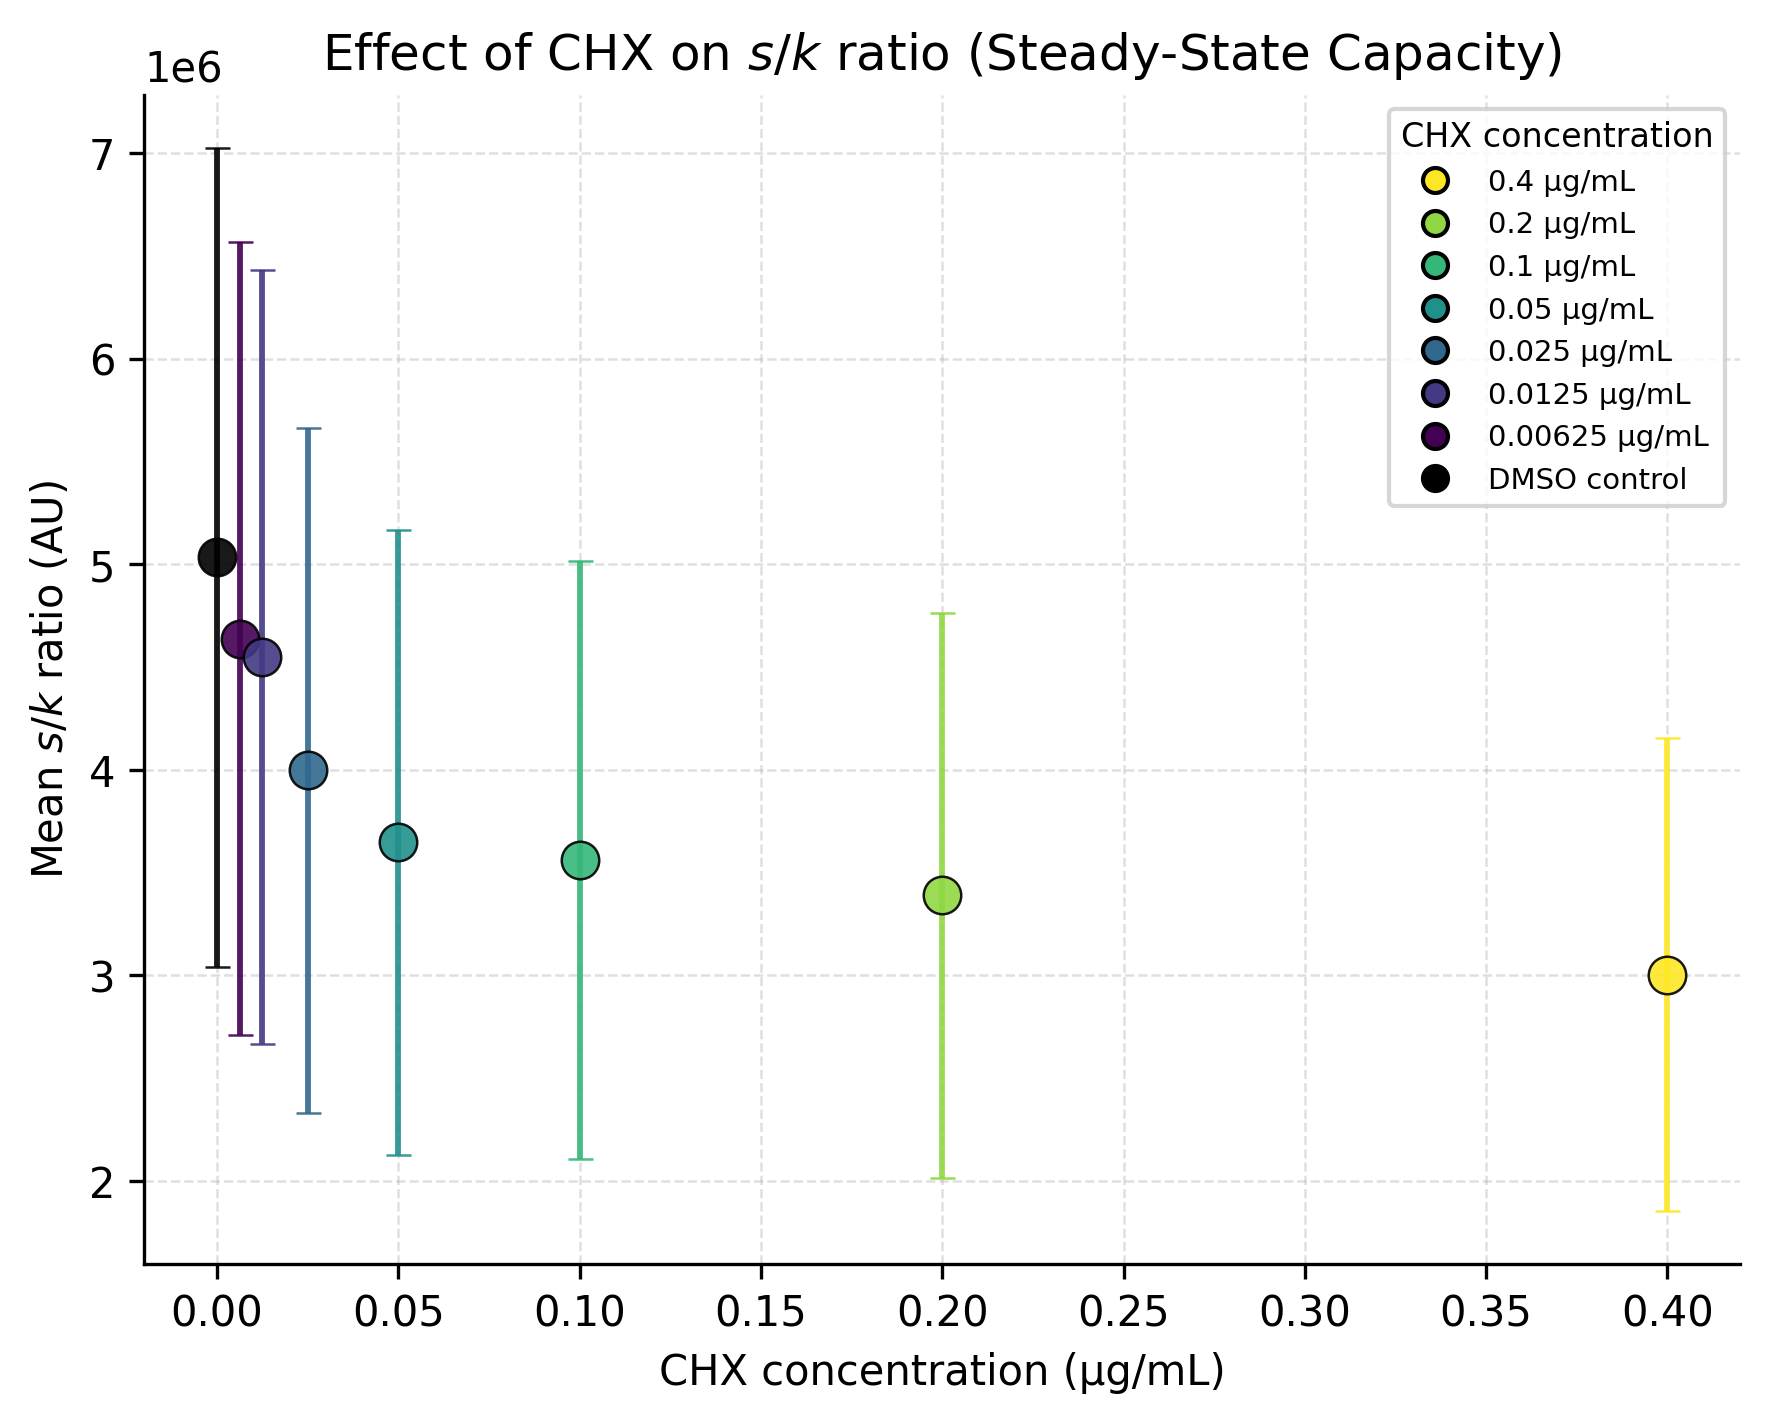

In [93]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=DPI)

for _, row in summary.iterrows():
    color = get_color(row["CHX_conc"])

    ax.errorbar(
        row["CHX_conc"], row["mean_sk"],
        yerr=row["std_sk"],          # vertical SD bars for the single-cell ratio
        fmt="o",
        markersize=9,
        color=color,
        ecolor=color,
        elinewidth=1.4,
        capsize=3,
        markeredgecolor="black",
        markeredgewidth=0.6,
        alpha=0.9,
        zorder=3,
    )

ax.set_xlabel("CHX concentration (μg/mL)")
ax.set_ylabel("Mean $s/k$ ratio (AU)")
ax.set_title("Effect of CHX on $s/k$ ratio (Steady-State Capacity)")

ax.legend(
    handles=make_legend_handles(linestyle=""),
    title="CHX concentration",
    fontsize=7,
    title_fontsize=8,
    loc="best",
)

ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()